In [1]:
import sys
sys.path.append("/var/www/python/Prod/nighthawk/")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from nighthawk.data.pipeline.common_functions import wind, load, genoutage
from nighthawk.util import dataframe_functions, bigquery_functions, connections, sql_functions
from nighthawk.models.portfolioOpt import ve_portfolio_constructor
from nighthawk.data.network import node
import gc
pd.set_option('display.max_columns', None)



In [2]:
# start_dt = '2022-01-11' # no Darwin data from 2022-01-01 to 2022-01-10 
start_dt = '2020-01-01'
end_dt = '2026-05-19'
opexchange = 'SPP'
strategy_list_dict = {'SPP': ['Darwin', 'Fourier']}
file_loc = '/mnt/disks/filedisk2a/Jessica/tmp/'

ve_port = ve_portfolio_constructor.VEPortfolioConstructor(opexchange)


## Fetch Data

In [3]:
portfolio_normal_df = pd.read_csv(file_loc + 'portfolio_df_aft_agg_ivst_May2026.csv')

In [5]:
portfolio_normal_df

,dt,strategy,hr,incdec,segment,node_num,bid_mw,bid_price,capacity
0,2020-01-01,Darwin,1,Decrement,1.0,6,5.625,50.852095,medium
1,2020-01-01,Darwin,1,Decrement,2.0,6,5.625,46.596586,medium
2,2020-01-01,Darwin,1,Decrement,3.0,6,5.625,35.494316,medium
3,2020-01-01,Darwin,1,Decrement,4.0,6,5.625,31.695665,medium
4,2020-01-01,Darwin,1,Decrement,5.0,6,5.625,30.199292,medium
...,...,...,...,...,...,...,...,...,...
13340250,2026-05-19,DarwinHighCap,24,Decrement,11.0,1735,1.350,39.847358,medium
13340251,2026-05-19,DarwinHighCap,24,Decrement,6.0,1745,1.350,24.635098,medium
13340252,2026-05-19,DarwinHighCap,24,Decrement,7.0,1745,1.350,18.831651,medium
13340253,2026-05-19,DarwinHighCap,24,Decrement,8.0,1745,1.350,13.840122,medium


In [7]:

# holdout
holdout_mon_lst = ['2020-03', '2020-06', '2020-10',
    '2021-02', '2021-05', '2021-09', 
    '2022-01',  '2022-07' '2022-12', 
    '2023-04', '2023-08', '2023-11',
    '2024-01', '2024-09', '2024-12', 
    '2025-03', '2025-07']
all_dt_df = pd.DataFrame.from_dict({'dt': pd.date_range(start_dt, end_dt)})
all_dt_df['yr'] = all_dt_df['dt'].dt.year
all_dt_df['mon'] = all_dt_df['dt'].dt.month
all_dt_df['yr_mon'] = all_dt_df['dt'].dt.strftime("%Y-%m")
all_dt_df['dt'] = all_dt_df['dt'].dt.strftime("%Y-%m-%d")
all_dt_df['holdout'] = np.where(all_dt_df['yr_mon'].isin(holdout_mon_lst), 1, 0)
    

ref_df = pd.read_csv(file_loc + 'reference_df.csv')
ref_df['dt'] = ref_df['dt'].astype(str)
ref_df['hr'] = ref_df['hr'].astype(int)
ref_df['node_num'] = ref_df['node_num'].astype(int)

# go_nogo_df
go_nogo_df = pd.read_csv(file_loc + 'go_nogo_days.csv')
go_nogo_df['dt'] = go_nogo_df['dt'].astype(str)
go_nogo_df['hr'] = go_nogo_df['hr'].astype(int)
print(go_nogo_df['nogo'].unique())

tier1_dt = set(go_nogo_df.loc[go_nogo_df['nogo'] == 1, 'dt'].values)
tier2_dt = set(go_nogo_df.loc[go_nogo_df['nogo'] == 2, 'dt'].values)


[0 2 1]


In [16]:
metric_cols = ['bid_mw', 'clear_mw', 'profit', 'profit_congestion', 'profit_slack',
       'profit_oprate', 'profit_pos',
       'profit_neg', 'investment']


def calculate_derived_profit_cols(df, da_total_col = 'da_total', min_mw = 0.1, bid_mw_col = 'bid_mw', bid_price_col = 'bid_price'):
    df = df[df['bid_mw'] > min_mw].copy()
    
    df['clear_mw'] = np.where(df['incdec'] == 'Decrement', df['bid_mw'] * (df['bid_price'] > df[da_total_col]),
                              df['bid_mw'] * (df['bid_price'] < df[da_total_col])).round(1)
    df['profit'] = np.where(df['incdec'] == 'Decrement', df['clear_mw'] *
                            (df['rt_total'] - df[da_total_col] -
                             df['op_rate_dec_a']),
                            df['clear_mw'] *
                            (df[da_total_col] - df['rt_total'] - df['op_rate_inc_a']))
    df['profit_congestion'] = np.where(df['incdec'] == 'Decrement',
                                       df['clear_mw'] *
                                       (df['rt_congestion'] -
                                        df['da_congestion']),
                                       df['clear_mw'] *
                                       (df['da_congestion'] - df['rt_congestion']))
    df['profit_slack'] = np.where(df['incdec'] == 'Decrement',
                                  df['clear_mw'] *
                                  (df['rt_slack'] - df['da_slack']),
                                  df['clear_mw'] *
                                  (df['da_slack'] - df['rt_slack']))
    df['profit_oprate'] = np.where(df['incdec'] == 'Decrement', -df['clear_mw'] * df['op_rate_dec_a'],
                                   -df['clear_mw'] * df['op_rate_inc_a'])

    if opexchange.upper() == 'SPP':  # collateral rule for SPP
        df['bidCollateral'] = np.where(df['incdec'] == 'Decrement', abs(df['bid_mw'] * df['bid_ref_price']),
                                       abs(df['bid_mw'] * df['offer_ref_price']))
        df['holdCollateral'] = np.where(df['incdec'] == 'Decrement', abs(df['clear_mw'] * df['bid_ref_price']),
                                        abs(df['clear_mw'] * df['offer_ref_price']))
    else:
        df['bidCollateral'] = np.where(df['incdec'] == 'Decrement', df['bid_mw'] * df['bid_ref_price'],
                                       df['bid_mw'] * df['offer_ref_price'])
        df['holdCollateral'] = np.where(df['incdec'] == 'Decrement', df['clear_mw'] * df['bid_ref_price'],
                                        df['clear_mw'] * df['offer_ref_price'])

    df['profit_pos'] = np.maximum(df['profit'], 0)
    df['profit_neg'] = np.minimum(df['profit'], 0)
    df['investment'] = df['clear_mw'] * df[da_total_col]
    df['investment'] = np.where(df['incdec'] == 'Increment', df['investment'], -df['investment'])
    return df

    
# portfolio_normal_df = portfolio.merge(go_nogo_df.loc[go_nogo_df['nogo'] == 0, ['dt', 'hr']])
portfolio_normal_df['bid_mw_bfr'] = portfolio_normal_df['bid_mw'].copy()

portfolio_normal_df = calculate_derived_profit_cols(portfolio_normal_df.merge(ref_df))

portfolio_normal_df['direction'] = np.where((portfolio_normal_df['rt_congestion'] - portfolio_normal_df['da_congestion'])*portfolio_normal_df['da_congestion'] < 0, 'short', 'long')

print(portfolio_normal_df.columns)
print(portfolio_normal_df['strategy'].unique())

Index(['dt', 'strategy', 'hr', 'incdec', 'segment', 'node_num', 'bid_mw',
       'bid_price', 'capacity', 'bid_mw_bfr', 'node_name', 'zone', 'state',
       'rep_zone', 'rep_zone_opexchange', 'broad_zone', 'baa_zone',
       'broad_zone_oprate_df', 'op_rate_inc_a', 'op_rate_dec_a',
       'op_rate_inc_f', 'op_rate_dec_f', 'da_congestion', 'da_total',
       'da_slack', 'rt_congestion', 'rt_total', 'rt_slack', 'bid_ref_price',
       'offer_ref_price', 'reserve_zone', 'clear_mw', 'profit',
       'profit_congestion', 'profit_slack', 'profit_oprate', 'bidCollateral',
       'holdCollateral', 'profit_pos', 'profit_neg', 'investment',
       'direction'],
      dtype='object')
['Darwin' 'Eigen' 'Fourier' 'DarwinHighCap']


## Investment Cut

In [18]:
# no cut
portfolio_normal_df['bid_mw'] = portfolio_normal_df['bid_mw_bfr'].copy()
_, _, temp = ve_port.get_portfolio_performance(portfolio_normal_df, get_lmp_and_oprate=False)
display(temp)

# no cut from 2023
_, _, temp = ve_port.get_portfolio_performance(portfolio_normal_df[portfolio_normal_df['dt'] >= '2023-01-01'], get_lmp_and_oprate=False)
display(temp)

,opexchange,NumOfDays,NumOfNodes,TotalProfit,CongestionProfit,SlackProfit,OperateProfit,totalCapital,AnnualProfitRate,congestionES,ROVar5,ROVar1,ROW,BidMW,HourlyTR,DailyTR,clearing_rate,top3MConc,top10NodeConc,top2ZoneConc,maxCollateralPerDay,worstDrawdown,TotalProfitPerBidMW,worstDailyProfit,CVar5DailyProfit,ProfitPerClearMW
0,SPP,2280,79.04,6.007575e+07,6.595401e+07,5.839535e+06,-1.309827e+07,6.136662e+06,1.567202,-53640.14,0.7507,0.2633,0.0653,4.034383e+07,2.6,5.43,0.25,0.09,0.18,0.4,5.727569e+06,-409093.66475,1.49,-403639,-79120,5.92


,opexchange,NumOfDays,NumOfNodes,TotalProfit,CongestionProfit,SlackProfit,OperateProfit,totalCapital,AnnualProfitRate,congestionES,ROVar5,ROVar1,ROW,BidMW,HourlyTR,DailyTR,clearing_rate,top3MConc,top10NodeConc,top2ZoneConc,maxCollateralPerDay,worstDrawdown,TotalProfitPerBidMW,worstDailyProfit,CVar5DailyProfit,ProfitPerClearMW
0,SPP,1203,62.55,2.585133e+07,2.891506e+07,2.412764e+06,-6.161983e+06,6.136662e+06,1.278138,-72443.45,0.5598,0.1929,0.0532,2.203728e+07,2.13,3.96,0.23,0.18,0.22,0.42,5.727569e+06,-409093.66475,1.17,-403639,-91628,5.11


In [ ]:
display(portfolio_normal_df.groupby('incdec').apply(lambda row: ve_port.get_portfolio_performance(row, get_lmp_and_oprate=False)[2]))
display(portfolio_normal_df[portfolio_normal_df['dt'] >= '2023-01-01'].groupby('incdec').apply(lambda row: ve_port.get_portfolio_performance(row, get_lmp_and_oprate=False)[2]))

,,opexchange,NumOfDays,NumOfNodes,TotalProfit,CongestionProfit,SlackProfit,OperateProfit,totalCapital,AnnualProfitRate,congestionES,ROVar5,ROVar1,ROW,BidMW,HourlyTR,DailyTR,clearing_rate,top3MConc,top10NodeConc,top2ZoneConc,maxCollateralPerDay,worstDrawdown,TotalProfitPerBidMW,worstDailyProfit,CVar5DailyProfit,ProfitPerClearMW
incdec,,,,,,,,,,,,,,,,,,,,,,,,,,,
Decrement,0,SPP,2280,61.72,2.515798e+07,2.931013e+07,-1.539858e+06,-3.056898e+06,3.692096e+06,1.090839,-30025.35,0.4251,0.2522,0.1342,1.950774e+07,1.99,3.23,0.25,0.10,0.28,0.46,3.429240e+06,-262856.67829,1.29,-82236,-37037,5.12
Increment,0,SPP,2280,64.32,3.491777e+07,3.664388e+07,7.379392e+06,-1.004137e+07,4.571084e+06,1.222884,-46130.19,0.3557,0.1335,0.0380,2.083609e+07,2.07,3.24,0.25,0.11,0.20,0.37,4.008621e+06,-562463.36009,1.68,-403503,-92319,6.67


,,opexchange,NumOfDays,NumOfNodes,TotalProfit,CongestionProfit,SlackProfit,OperateProfit,totalCapital,AnnualProfitRate,congestionES,ROVar5,ROVar1,ROW,BidMW,HourlyTR,DailyTR,clearing_rate,top3MConc,top10NodeConc,top2ZoneConc,maxCollateralPerDay,worstDrawdown,TotalProfitPerBidMW,worstDailyProfit,CVar5DailyProfit,ProfitPerClearMW
incdec,,,,,,,,,,,,,,,,,,,,,,,,,,,
Decrement,0,SPP,1203,52.33,1.090496e+07,1.236942e+07,-2.348270e+05,-1.417933e+06,3.682676e+06,0.898438,-38400.05,0.3325,0.2235,0.1102,1.038728e+07,1.74,2.61,0.24,0.17,0.34,0.48,3.429240e+06,-253435.97145,1.05,-82236,-37573,4.43
Increment,0,SPP,1203,55.22,1.494636e+07,1.654563e+07,2.647591e+06,-4.744050e+06,4.571084e+06,0.992073,-61156.42,0.2345,0.0912,0.0308,1.165000e+07,1.74,2.50,0.22,0.19,0.24,0.38,4.008621e+06,-562463.36009,1.28,-403503,-104229,5.75


In [8]:
def get_da_total_pred(opexchange, start_dt, end_dt): 

    start_dt_1 = start_dt
    start_dt_2 = start_dt

    node_obj = node.Node(node_nums=[636], market=opexchange)
    hub_price_df = node_obj.get_price(start_dt=start_dt_1, end_dt=end_dt, component=['LMP'], type=['DA'])
    hub_price_df['dt'] = hub_price_df['dt'].astype(str)
    hub_price_df = dataframe_functions.create_dthr_df_from_date_range(start_dt_1, end_dt).merge(hub_price_df, how='left')
    hub_price_df = hub_price_df.drop(columns=['node_num']).set_index(['dt', 'hr']).interpolate(method='linear', axis=0).reset_index()
    hub_price_df = hub_price_df.sort_values(['dt', 'hr']).reset_index(drop=True)

    n_day_slack_ls = [7, 30, ]
    for n_day_slack in n_day_slack_ls:
        tmp_hrly = hub_price_df.groupby('hr', as_index=False, group_keys=False)[['da_total']].rolling(
                    n_day_slack).mean()
        for x in ['da_total']: # ['da_slack', 'rt_slack']
            nhrs_shift = 24 if x == 'da_total' else 48
            col_name = x + f'_avg{n_day_slack}D_hrly'
            hub_price_df[col_name] = tmp_hrly[x]
            # we want to use information as of 2 days old
            hub_price_df[col_name] = hub_price_df[col_name].shift(nhrs_shift)

        tmp_daily = hub_price_df.rolling(n_day_slack*24).mean(numeric_only=True)
        for x in ['da_total']: # ['da_slack', 'rt_slack']
            ndays_shift = 1 if x == 'da_total' else 2
            col_name = x + f'_avg{n_day_slack}D'

            hub_price_df[col_name] = tmp_daily[x]
            temp = hub_price_df.loc[hub_price_df['hr'] == 24, ['dt', col_name]]
            temp[col_name] = temp[col_name].shift(ndays_shift)
            hub_price_df = hub_price_df.drop(columns = col_name).merge(temp)

    def get_gas_price(start_dt, end_dt):
    #     henryHub, tetcoM3Hub, consumersHub, transcoHub, panHandleHub
        dthr = dataframe_functions.create_dthr_df_from_date_range(start_dt, end_dt)    

        gas_forecast = sql_functions.download_df_from_sql_db(f""" SELECT dt, henryHub as natural_gas_henry_f, 
        panHandleHub as natural_gas_panhandle_f FROM 
                odessa_VirtualStrategy_MISO.iceVariables where dt BETWEEN '{start_dt}' and '{end_dt}'
                """)
        gas_forecast['dt'] = gas_forecast['dt'].astype(str)
        gas_forecast['natural_gas_henry_f'] = gas_forecast['natural_gas_henry_f'].replace(0, np.nan)
        gas_forecast['natural_gas_panhandle_f'] = gas_forecast['natural_gas_panhandle_f'].replace(0, np.nan)
        gas_forecast['natural_gas_mix_f'] = gas_forecast[['natural_gas_henry_f', 'natural_gas_panhandle_f']].max(axis=1)
    #     gas_forecast['natural_gas_mix_f'] = np.where(gas_forecast['natural_gas_panhandle_f'].isna(), 
    #                                                  gas_forecast['natural_gas_henry_f'], gas_forecast['natural_gas_panhandle_f'])
        gas_forecast = pd.merge(dthr[['dt']].drop_duplicates(), gas_forecast, on=['dt'], how='left')
        gas_forecast = gas_forecast.set_index('dt').interpolate(method='linear', axis=0).bfill().ffill().reset_index()

        return gas_forecast

    # daily gas price
    henry_start_dt = '2018-09-26'
    panhandle_start_dt = '2019-03-09'
    gas_forecast = get_gas_price(start_dt_2, end_dt)
    gas_forecast['natural_gas_henry_f'] = np.where(gas_forecast['dt'] < henry_start_dt, np.nan, gas_forecast['natural_gas_henry_f'])
    gas_forecast['natural_gas_mix_f'] = np.where(gas_forecast['dt'] < henry_start_dt, np.nan, gas_forecast['natural_gas_mix_f'])
    gas_forecast['natural_gas_panhandle_f'] = np.where(gas_forecast['dt'] < panhandle_start_dt, np.nan, gas_forecast['natural_gas_panhandle_f'])

    hub_price_df = hub_price_df.merge(gas_forecast[['dt', 'natural_gas_mix_f']])
    hub_price_df = hub_price_df.set_index(['dt', 'hr']).interpolate(method='linear', axis=0).reset_index()
    
    return hub_price_df

In [9]:
hub_price_df = get_da_total_pred(opexchange, start_dt, end_dt)

hub_price_df = dataframe_functions.cross_join(hub_price_df, pd.DataFrame({'incdec': ['Increment', 'Decrement']}))

display(hub_price_df.head())
display(hub_price_df.tail())

,dt,hr,da_total,da_total_avg7D_hrly,da_total_avg7D,da_total_avg30D_hrly,da_total_avg30D,natural_gas_mix_f,incdec
0,2020-01-01,1,4.7860,NaN,NaN,NaN,NaN,2.05,Increment
1,2020-01-01,1,4.7860,NaN,NaN,NaN,NaN,2.05,Decrement
2,2020-01-01,2,3.3743,NaN,NaN,NaN,NaN,2.05,Increment
3,2020-01-01,2,3.3743,NaN,NaN,NaN,NaN,2.05,Decrement
4,2020-01-01,3,1.8759,NaN,NaN,NaN,NaN,2.05,Increment


,dt,hr,da_total,da_total_avg7D_hrly,da_total_avg7D,da_total_avg30D_hrly,da_total_avg30D,natural_gas_mix_f,incdec
111883,2026-05-19,22,32.194401,14.513929,12.914252,15.830643,17.362781,3.09,Decrement
111884,2026-05-19,23,24.308500,6.840214,12.914252,8.084820,17.362781,3.09,Increment
111885,2026-05-19,23,24.308500,6.840214,12.914252,8.084820,17.362781,3.09,Decrement
111886,2026-05-19,24,21.651501,-1.711571,12.914252,1.669507,17.362781,3.09,Increment
111887,2026-05-19,24,21.651501,-1.711571,12.914252,1.669507,17.362781,3.09,Decrement


In [10]:
# get daily reference price by gas price and then adjust to hourly reference price by incdec
p = np.poly1d(
                [0.58, 2.45, 12.23])  # [a, b, c]: a*(x**2) + b*x + c, parameters are from polynomial regression
hub_price_df['ref_price_hrly_1'] = p(hub_price_df['natural_gas_mix_f']) * (
        hub_price_df['da_total_avg30D_hrly'] / hub_price_df['da_total_avg30D'])

# get daily incdec adjusted reference price 
hub_price_df['ref_price_hrly_2'] = np.where(hub_price_df['incdec'] == 'Decrement', hub_price_df['natural_gas_mix_f']*10*0.5, hub_price_df['natural_gas_mix_f']*10*1.5)

# get daily reference price by gas price and then adjust to hourly reference price by incdec
hub_price_df['ref_price_hrly_3'] = hub_price_df['natural_gas_mix_f']*10  * (
        hub_price_df['da_total_avg30D_hrly'] / hub_price_df['da_total_avg30D'])
hub_price_df['ref_price_hrly_3'] = np.where(hub_price_df['incdec'] == 'Decrement', hub_price_df['ref_price_hrly_3']*0.5, hub_price_df['ref_price_hrly_3']*1.5)


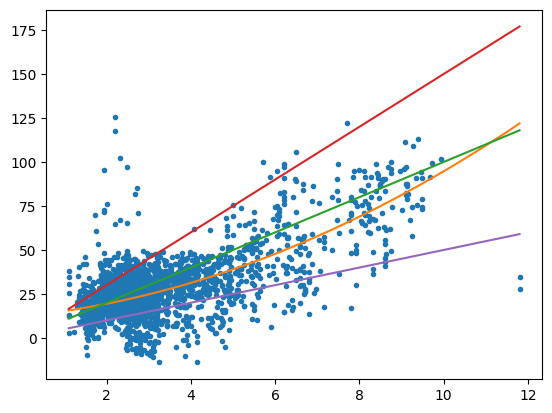

In [11]:

# daily level 
gas_var = 'natural_gas_mix_f'
y_var = 'da_total'
temp = hub_price_df[~(hub_price_df['dt'].isin(set(tier2_dt))|hub_price_df['dt'].isin(tier1_dt)|hub_price_df[gas_var].isna()|hub_price_df[y_var].isna())]
temp = temp.groupby('dt')[['natural_gas_mix_f', 'da_total']].mean().reset_index()

x = temp[gas_var]
y = temp[y_var]

xp = np.linspace(x.min(), x.max(), 100)
p_1 = np.poly1d([0.58, 2.45, 12.23])
p_2 = np.poly1d([0, 10, 0])
p_3 = np.poly1d([0, 10*1.5, 0])
p_4 = np.poly1d([0, 10*0.5, 0])
# plt.plot(x, y, '.', x, p(x), '-')
plt.plot(x, y, '.', xp, p_1(xp), '-', xp, p_2(xp), '-', xp, p_3(xp), '-', xp, p_4(xp), '-')
plt.show()

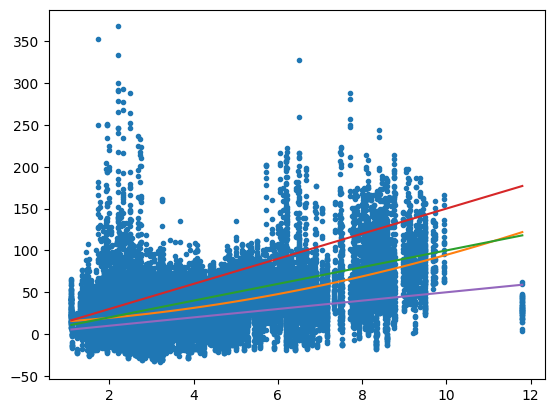

In [12]:

# hourly level 
gas_var = 'natural_gas_mix_f'
y_var = 'da_total'
temp = hub_price_df[~(hub_price_df['dt'].isin(set(tier2_dt))|hub_price_df['dt'].isin(tier1_dt)|hub_price_df[gas_var].isna()|hub_price_df[y_var].isna())]
temp = temp.groupby(['dt', 'hr'])[['natural_gas_mix_f', 'da_total']].mean().reset_index()

x = temp[gas_var]
y = temp[y_var]

xp = np.linspace(x.min(), x.max(), 100)
p_1 = np.poly1d([0.58, 2.45, 12.23])
p_2 = np.poly1d([0, 10, 0])
p_3 = np.poly1d([0, 10*1.5, 0])
p_4 = np.poly1d([0, 10*0.5, 0])
# plt.plot(x, y, '.', x, p(x), '-')
plt.plot(x, y, '.', xp, p_1(xp), '-', xp, p_2(xp), '-', xp, p_3(xp), '-', xp, p_4(xp), '-')
plt.show()

In [13]:
def calculate_daily_estimate(df):
    portfolio_daily_df = df.merge(hub_price_df[['dt', 'hr', 'incdec'] + [col for col in hub_price_df.columns if 'ref_price_hrly' in col]])

    ref_price_cols = [col for col in portfolio_daily_df.columns if 'ref_price_hrly' in col]
    for da_total_col in ref_price_cols:
        portfolio_daily_df[da_total_col] = np.where(portfolio_daily_df['incdec'] == 'Decrement', portfolio_daily_df['bid_mw'] * (portfolio_daily_df['bid_price'] - portfolio_daily_df[da_total_col]),
                                portfolio_daily_df['bid_mw'] * (portfolio_daily_df[da_total_col] - portfolio_daily_df['bid_price']))
        portfolio_daily_df[da_total_col] = np.where(portfolio_daily_df[da_total_col] < 0, 0, portfolio_daily_df[da_total_col])

    portfolio_daily_nodal_incdec_df = portfolio_daily_df.groupby(['dt', 'incdec', 'node_num'])[['bid_mw', 'clear_mw', 'profit',
       'profit_congestion', 'profit_slack', 'profit_pos', 'profit_neg'] + ref_price_cols].sum().reset_index()
    portfolio_daily_incdec_df = portfolio_daily_df.groupby(['dt', 'incdec'])[['bid_mw', 'clear_mw', 'profit',
       'profit_congestion', 'profit_slack', 'profit_pos', 'profit_neg'] + ref_price_cols].sum().reset_index()

    return portfolio_daily_nodal_incdec_df, portfolio_daily_incdec_df

In [14]:
_, portfolio_daily_incdec_df = calculate_daily_estimate(portfolio_normal_df[['dt', 'hr', 'incdec', 'segment', 'node_num', 'bid_mw', 'bid_price', 'da_total', 'clear_mw', 'profit',
       'profit_congestion', 'profit_slack', 'profit_pos', 'profit_neg']])


In [15]:
def display_investment_cut_performance(temp_portfolio_daily_incdec_df, col, q_lst):
    
    temp_portfolio_daily_incdec_df[col + '_bkt_label'] = pd.qcut(temp_portfolio_daily_incdec_df[col], q_lst)
    
    temp = temp_portfolio_daily_incdec_df.groupby([col + '_bkt_label']).agg({col: 'max', 'profit': 'sum', 'bid_mw': 'sum', 'clear_mw': 'sum', 'profit_congestion': 'sum',
    'profit_slack': 'sum', 'profit_pos': 'sum', 'profit_neg': 'sum'}).reset_index()
    temp['bid_mw_pct'] = temp['bid_mw'] / temp['bid_mw'].sum()
    temp['profit_pct'] = temp['profit'] / temp['profit'].sum()
    temp['profit_slack_pct'] = temp['profit_slack'] / temp['profit_slack'].sum()
    temp['tr'] = -temp['profit_pos'] / temp['profit_neg']
    temp['ppbw'] = temp['profit'] / temp['bid_mw']
    temp['ppcw'] = temp['profit'] / temp['clear_mw']
    display(temp.round(2))

In [16]:
q_lst = [0, 0.1, 0.5, 0.9, 0.95, 0.97, 0.985, 0.99, 0.995, 1]

# ref_price_cols = [col for col in hub_price_df.columns if 'ref_price_hrly' in col]
ref_price_cols = ['ref_price_hrly_2']


In [17]:
# Decrement
temp_portfolio_daily_incdec_df = portfolio_daily_incdec_df[portfolio_daily_incdec_df['incdec'] == 'Decrement']
for col in ref_price_cols:
   display_investment_cut_performance(temp_portfolio_daily_incdec_df, col, q_lst)

,ref_price_hrly_2_bkt_label,ref_price_hrly_2,profit,bid_mw,clear_mw,profit_congestion,profit_slack,profit_pos,profit_neg,bid_mw_pct,profit_pct,profit_slack_pct,tr,ppbw,ppcw
0,"(3285.711, 32778.317]",32713.71,2403275.82,1219102.54,281944.3,2730223.99,-81642.29,4559767.45,-2156491.63,0.06,0.10,0.05,2.11,1.97,8.52
1,"(32778.317, 108241.47]",108216.85,9546128.24,7120270.78,1741970.2,11090027.35,-531828.62,22067822.08,-12521693.84,0.36,0.38,0.35,1.76,1.34,5.48
2,"(108241.47, 217261.931]",217253.10,11259125.64,8845421.17,2372202.3,11721716.21,627287.65,29452038.22,-18192912.59,0.45,0.45,-0.41,1.62,1.27,4.75
3,"(217261.931, 257037.607]",257022.80,951622.19,1074567.37,256923.3,1937698.26,-868421.24,3771919.49,-2820297.30,0.06,0.04,0.56,1.34,0.89,3.70
4,"(257037.607, 289964.411]",289884.23,555405.26,488081.15,112601.4,721477.11,-147926.09,1633344.10,-1077938.83,0.03,0.02,0.10,1.52,1.14,4.93
5,"(289964.411, 326505.158]",324576.21,88141.26,356453.18,80775.5,431788.12,-293085.28,1057977.23,-969835.98,0.02,0.00,0.19,1.09,0.25,1.09
6,"(326505.158, 362016.307]",361416.96,115989.72,133168.59,23359.2,193903.64,-53619.06,407587.11,-291597.39,0.01,0.00,0.03,1.40,0.87,4.97
7,"(362016.307, 408286.08]",407248.84,178434.89,134746.25,18449.6,261355.00,-54555.68,395328.78,-216893.89,0.01,0.01,0.04,1.82,1.32,9.67
8,"(408286.08, 629581.433]",629581.43,59857.17,135931.03,21385.7,221944.13,-136067.12,389552.43,-329695.26,0.01,0.00,0.09,1.18,0.44,2.80


In [18]:
# Decrement and >= 2023
temp_portfolio_daily_incdec_df = portfolio_daily_incdec_df[(portfolio_daily_incdec_df['dt'] >= '2023-01-01') & (portfolio_daily_incdec_df['incdec'] == 'Decrement')]
for col in ref_price_cols:
    display_investment_cut_performance(temp_portfolio_daily_incdec_df, col, q_lst)

,ref_price_hrly_2_bkt_label,ref_price_hrly_2,profit,bid_mw,clear_mw,profit_congestion,profit_slack,profit_pos,profit_neg,bid_mw_pct,profit_pct,profit_slack_pct,tr,ppbw,ppcw
0,"(4094.9429999999998, 46002.173]",45981.35,635043.82,741262.01,165495.8,882007.28,-154000.33,2007040.67,-1371996.85,0.07,0.06,0.66,1.46,0.86,3.84
1,"(46002.173, 121274.353]",121274.35,4167315.79,3953063.51,877508.4,4790236.13,-108769.40,11725543.03,-7558227.24,0.38,0.38,0.46,1.55,1.05,4.75
2,"(121274.353, 222119.654]",221481.40,5321024.19,4535600.71,1129906.0,5350394.21,522237.32,15063603.98,-9742579.79,0.44,0.49,-2.22,1.55,1.17,4.71
3,"(222119.654, 248260.981]",248160.46,348724.71,555449.43,139541.8,596522.29,-202409.20,1857957.15,-1509232.44,0.05,0.03,0.86,1.23,0.63,2.50
4,"(248260.981, 275143.538]",274602.89,542810.86,235923.40,66429.5,569426.45,-30340.99,1187787.93,-644977.07,0.02,0.05,0.13,1.84,2.30,8.17
5,"(275143.538, 306475.442]",302326.57,20386.69,180689.86,40320.9,87503.20,-49959.37,577365.46,-556978.77,0.02,0.00,0.21,1.04,0.11,0.51
6,"(306475.442, 316236.894]",313999.18,82246.98,55132.10,13974.3,51481.95,32387.79,190720.42,-108473.45,0.01,0.01,-0.14,1.76,1.49,5.89
7,"(316236.894, 337967.616]",328037.67,-167556.24,57563.06,19392.3,-13428.62,-147133.65,71664.19,-239220.42,0.01,-0.02,0.63,0.30,-2.91,-8.64
8,"(337967.616, 545277.544]",545277.54,-45032.54,72596.82,11609.4,55281.47,-96839.18,172122.15,-217154.68,0.01,-0.00,0.41,0.79,-0.62,-3.88


In [19]:
# Icrement
temp_portfolio_daily_incdec_df = portfolio_daily_incdec_df[portfolio_daily_incdec_df['incdec'] == 'Increment']
for col in ref_price_cols:
    display_investment_cut_performance(temp_portfolio_daily_incdec_df, col, q_lst)

,ref_price_hrly_2_bkt_label,ref_price_hrly_2,profit,bid_mw,clear_mw,profit_congestion,profit_slack,profit_pos,profit_neg,bid_mw_pct,profit_pct,profit_slack_pct,tr,ppbw,ppcw
0,"(522.539, 30297.083]",30194.56,1179189.69,1243838.97,235421.6,1409375.63,395171.55,4485656.64,-3306466.95,0.06,0.03,0.05,1.36,0.95,5.01
1,"(30297.083, 169963.451]",169953.77,9266427.93,7125654.95,1700141.3,10550684.65,1212315.76,23669158.63,-14402730.69,0.34,0.27,0.16,1.64,1.30,5.45
2,"(169963.451, 508955.953]",508936.37,16250767.59,9551666.41,2532794.2,16569327.19,3495205.63,37971375.06,-21720607.48,0.46,0.47,0.47,1.75,1.70,6.42
3,"(508955.953, 648459.649]",648441.60,3411508.58,1394845.93,379526.9,3628695.72,577366.14,6482653.27,-3071144.70,0.07,0.10,0.08,2.11,2.45,8.99
4,"(648459.649, 781265.785]",773175.60,2048748.98,578752.28,172227.5,1602952.31,1011130.37,3163781.55,-1115032.57,0.03,0.06,0.14,2.84,3.54,11.90
5,"(781265.785, 938006.383]",937394.94,952697.84,436436.27,94485.2,1080463.90,198939.15,1648556.79,-695858.95,0.02,0.03,0.03,2.37,2.18,10.08
6,"(938006.383, 991378.679]",991139.57,918831.26,169319.54,42240.6,872927.40,209987.22,1104284.07,-185452.81,0.01,0.03,0.03,5.95,5.43,21.75
7,"(991378.679, 1088952.753]",1073639.10,350478.57,160203.19,38344.4,429849.41,45503.64,557095.61,-206617.04,0.01,0.01,0.01,2.70,2.19,9.14
8,"(1088952.753, 1525264.052]",1525264.05,539119.85,175372.09,42983.2,499603.04,233773.02,798911.05,-259791.20,0.01,0.02,0.03,3.08,3.07,12.54


In [20]:
# Increment and >= 2023
temp_portfolio_daily_incdec_df = portfolio_daily_incdec_df[(portfolio_daily_incdec_df['dt'] >= '2023-01-01') & (portfolio_daily_incdec_df['incdec'] == 'Increment')]
for col in ref_price_cols:
    display_investment_cut_performance(temp_portfolio_daily_incdec_df, col, q_lst)

,ref_price_hrly_2_bkt_label,ref_price_hrly_2,profit,bid_mw,clear_mw,profit_congestion,profit_slack,profit_pos,profit_neg,bid_mw_pct,profit_pct,profit_slack_pct,tr,ppbw,ppcw
0,"(522.539, 19930.49]",19912.47,539704.47,689890.70,117323.2,638510.82,267579.84,2412558.72,-1872854.25,0.06,0.04,0.10,1.29,0.78,4.60
1,"(19930.49, 132611.342]",132611.34,4051062.75,3873323.91,766509.1,5449055.37,-151871.80,13064511.49,-9013448.74,0.33,0.27,-0.06,1.45,1.05,5.29
2,"(132611.342, 414626.775]",413402.99,6854924.95,5398243.03,1238380.1,7352090.25,1212346.75,20251067.04,-13396142.09,0.46,0.46,0.46,1.51,1.27,5.54
3,"(414626.775, 527364.183]",526072.77,1272424.00,817911.12,210463.1,1238219.85,440252.14,3003536.45,-1731112.44,0.07,0.09,0.17,1.74,1.56,6.05
4,"(527364.183, 601021.207]",598953.66,792204.30,334742.14,98380.0,617161.73,364163.25,1412963.26,-620758.96,0.03,0.05,0.14,2.28,2.37,8.05
5,"(601021.207, 660450.16]",653672.96,521380.88,256572.51,77881.3,523533.41,103502.63,1201288.10,-679907.22,0.02,0.03,0.04,1.77,2.03,6.69
6,"(660450.16, 725752.217]",725600.96,362868.25,94161.27,39182.9,310560.01,152658.05,649181.79,-286313.54,0.01,0.02,0.06,2.27,3.85,9.26
7,"(725752.217, 825783.149]",813268.90,231076.19,80241.31,28297.9,80215.85,233322.59,368635.14,-137558.95,0.01,0.02,0.09,2.68,2.88,8.17
8,"(825783.149, 963316.552]",963316.55,320715.09,104909.55,21683.3,336287.33,25637.09,423628.24,-102913.15,0.01,0.02,0.01,4.12,3.06,14.79


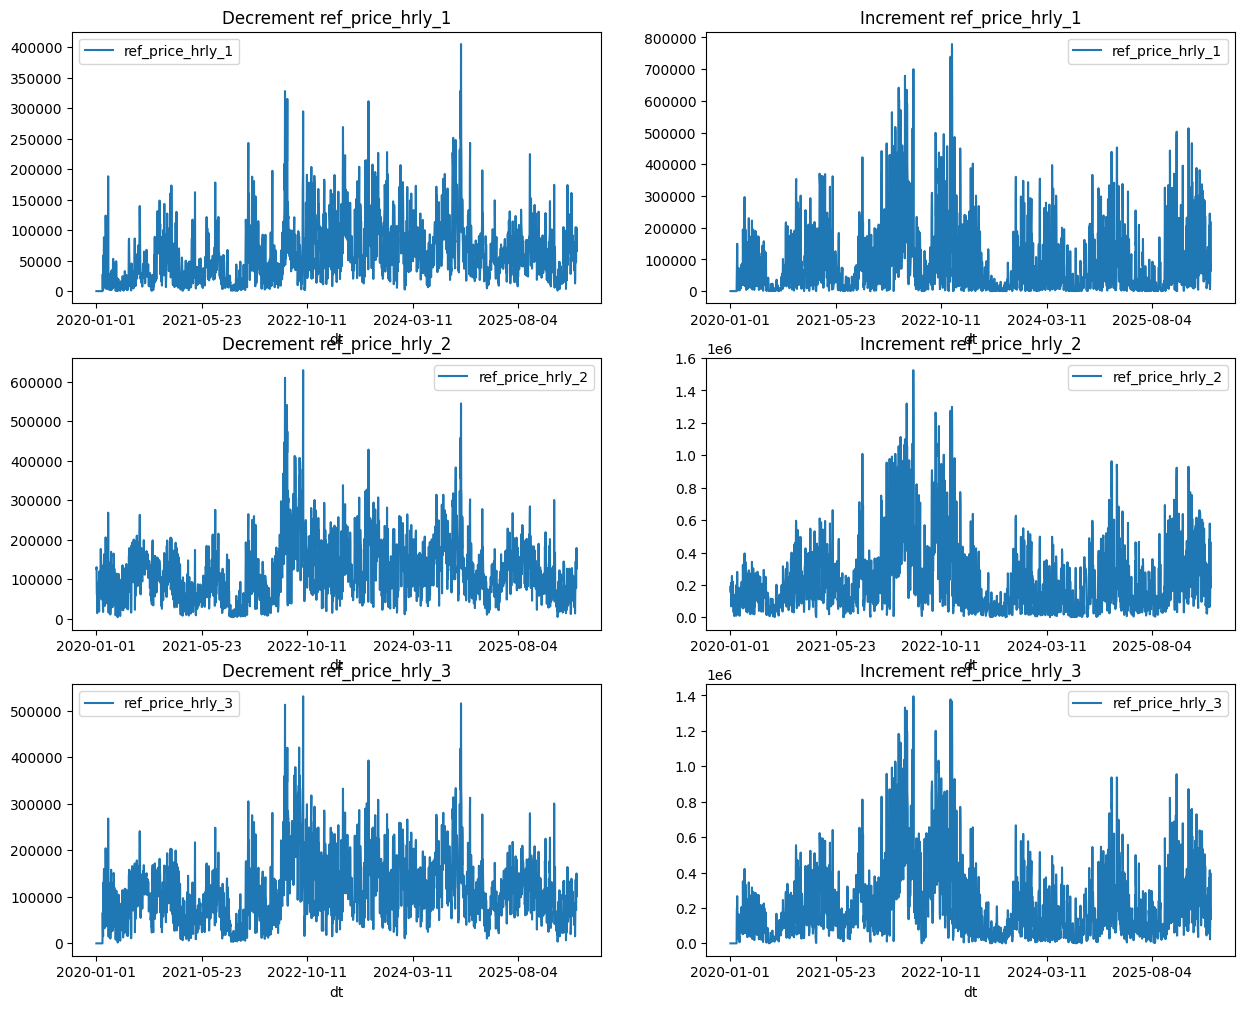

In [21]:
ref_price_cols = [col for col in hub_price_df.columns if 'ref_price_hrly' in col]
# ref_price_cols = ['ref_price_hrly_2']

incdec_lst = ['Decrement', 'Increment']
fig, ax = plt.subplots(len(ref_price_cols), 2, figsize=(15,12))
for col in ref_price_cols:
    for incdec in incdec_lst:
        portfolio_daily_incdec_df[portfolio_daily_incdec_df['incdec'] == incdec].plot('dt', [col], ax=ax[ref_price_cols.index(col), incdec_lst.index(incdec)], title = incdec + ' ' + col)


In [22]:


# normal day investment cut for all days
investment_col = 'ref_price_hrly_2'
dec_investment_cutoff = 800000
inc_investment_cutoff = 1600000

portfolio_daily_incdec_df['multipler'] = 1
portfolio_daily_incdec_df['multipler'] = np.where((portfolio_daily_incdec_df[investment_col] > dec_investment_cutoff) & (portfolio_daily_incdec_df['incdec'] == 'Decrement'), 
dec_investment_cutoff/portfolio_daily_incdec_df[investment_col], portfolio_daily_incdec_df['multipler'])
portfolio_daily_incdec_df['multipler'] = np.where((portfolio_daily_incdec_df[investment_col] > inc_investment_cutoff) & (portfolio_daily_incdec_df['incdec'] == 'Increment'), 
inc_investment_cutoff/portfolio_daily_incdec_df[investment_col], portfolio_daily_incdec_df['multipler'])


portfolio_normal_df = portfolio_normal_df.drop(columns=['multipler'], errors='ignore').merge(portfolio_daily_incdec_df[['dt', 'incdec', 'multipler']])
portfolio_normal_df['bid_mw'] = portfolio_normal_df['bid_mw_bfr']*portfolio_normal_df['multipler']
portfolio_normal_df = portfolio_normal_df.drop(columns=['multipler'])

In [23]:
_, _, temp = ve_port.get_portfolio_performance(portfolio_normal_df, get_lmp_and_oprate=False)
display(temp)
_, _, temp = ve_port.get_portfolio_performance(portfolio_normal_df[portfolio_normal_df['dt'] >= '2023-01-01'], get_lmp_and_oprate=False)
display(temp)

,opexchange,NumOfDays,NumOfNodes,TotalProfit,CongestionProfit,SlackProfit,OperateProfit,totalCapital,AnnualProfitRate,congestionES,ROVar5,ROVar1,ROW,BidMW,HourlyTR,DailyTR,clearing_rate,top3MConc,top10NodeConc,top2ZoneConc,maxCollateralPerDay,worstDrawdown,TotalProfitPerBidMW,worstDailyProfit,CVar5DailyProfit,ProfitPerClearMW
0,SPP,2280,79.04,6.007575e+07,6.595401e+07,5.839535e+06,-1.309827e+07,6.136662e+06,1.567202,-53640.14,0.7507,0.2633,0.0653,4.034383e+07,2.6,5.43,0.25,0.09,0.18,0.4,5.727569e+06,-409093.66475,1.49,-403639,-79120,5.92


,opexchange,NumOfDays,NumOfNodes,TotalProfit,CongestionProfit,SlackProfit,OperateProfit,totalCapital,AnnualProfitRate,congestionES,ROVar5,ROVar1,ROW,BidMW,HourlyTR,DailyTR,clearing_rate,top3MConc,top10NodeConc,top2ZoneConc,maxCollateralPerDay,worstDrawdown,TotalProfitPerBidMW,worstDailyProfit,CVar5DailyProfit,ProfitPerClearMW
0,SPP,1203,62.55,2.585133e+07,2.891506e+07,2.412764e+06,-6.161983e+06,6.136662e+06,1.278138,-72443.45,0.5598,0.1929,0.0532,2.203728e+07,2.13,3.96,0.23,0.18,0.22,0.42,5.727569e+06,-409093.66475,1.17,-403639,-91628,5.11


In [24]:
display(portfolio_normal_df.groupby('incdec').apply(lambda row: ve_port.get_portfolio_performance(row, get_lmp_and_oprate=False)[2]))
display(portfolio_normal_df[portfolio_normal_df['dt'] >= '2023-01-01'].groupby('incdec').apply(lambda row: ve_port.get_portfolio_performance(row, get_lmp_and_oprate=False)[2]))


,,opexchange,NumOfDays,NumOfNodes,TotalProfit,CongestionProfit,SlackProfit,OperateProfit,totalCapital,AnnualProfitRate,congestionES,ROVar5,ROVar1,ROW,BidMW,HourlyTR,DailyTR,clearing_rate,top3MConc,top10NodeConc,top2ZoneConc,maxCollateralPerDay,worstDrawdown,TotalProfitPerBidMW,worstDailyProfit,CVar5DailyProfit,ProfitPerClearMW
incdec,,,,,,,,,,,,,,,,,,,,,,,,,,,
Decrement,0,SPP,2280,61.72,2.515798e+07,2.931013e+07,-1.539858e+06,-3.056898e+06,3.692096e+06,1.090839,-30025.35,0.4251,0.2522,0.1342,1.950774e+07,1.99,3.23,0.25,0.10,0.28,0.46,3.429240e+06,-262856.67829,1.29,-82236,-37037,5.12
Increment,0,SPP,2280,64.32,3.491777e+07,3.664388e+07,7.379392e+06,-1.004137e+07,4.571084e+06,1.222884,-46130.19,0.3557,0.1335,0.0380,2.083609e+07,2.07,3.24,0.25,0.11,0.20,0.37,4.008621e+06,-562463.36009,1.68,-403503,-92319,6.67


,,opexchange,NumOfDays,NumOfNodes,TotalProfit,CongestionProfit,SlackProfit,OperateProfit,totalCapital,AnnualProfitRate,congestionES,ROVar5,ROVar1,ROW,BidMW,HourlyTR,DailyTR,clearing_rate,top3MConc,top10NodeConc,top2ZoneConc,maxCollateralPerDay,worstDrawdown,TotalProfitPerBidMW,worstDailyProfit,CVar5DailyProfit,ProfitPerClearMW
incdec,,,,,,,,,,,,,,,,,,,,,,,,,,,
Decrement,0,SPP,1203,52.33,1.090496e+07,1.236942e+07,-2.348270e+05,-1.417933e+06,3.682676e+06,0.898438,-38400.05,0.3325,0.2235,0.1102,1.038728e+07,1.74,2.61,0.24,0.17,0.34,0.48,3.429240e+06,-253435.97145,1.05,-82236,-37573,4.43
Increment,0,SPP,1203,55.22,1.494636e+07,1.654563e+07,2.647591e+06,-4.744050e+06,4.571084e+06,0.992073,-61156.42,0.2345,0.0912,0.0308,1.165000e+07,1.74,2.50,0.22,0.19,0.24,0.38,4.008621e+06,-562463.36009,1.28,-403503,-104229,5.75


In [25]:


# normal day investment cut for all days
investment_col = 'ref_price_hrly_2'
dec_investment_cutoff = 450000
inc_investment_cutoff = 1200000

portfolio_daily_incdec_df['multipler'] = 1
portfolio_daily_incdec_df['multipler'] = np.where((portfolio_daily_incdec_df[investment_col] > dec_investment_cutoff) & (portfolio_daily_incdec_df['incdec'] == 'Decrement'), 
dec_investment_cutoff/portfolio_daily_incdec_df[investment_col], portfolio_daily_incdec_df['multipler'])
portfolio_daily_incdec_df['multipler'] = np.where((portfolio_daily_incdec_df[investment_col] > inc_investment_cutoff) & (portfolio_daily_incdec_df['incdec'] == 'Increment'), 
inc_investment_cutoff/portfolio_daily_incdec_df[investment_col], portfolio_daily_incdec_df['multipler'])


portfolio_normal_df = portfolio_normal_df.drop(columns=['multipler'], errors='ignore').merge(portfolio_daily_incdec_df[['dt', 'incdec', 'multipler']])
portfolio_normal_df['bid_mw'] = portfolio_normal_df['bid_mw_bfr']*portfolio_normal_df['multipler']
portfolio_normal_df = portfolio_normal_df.drop(columns=['multipler'])

In [26]:
_, _, temp = ve_port.get_portfolio_performance(portfolio_normal_df, get_lmp_and_oprate=False)
display(temp)
_, _, temp = ve_port.get_portfolio_performance(portfolio_normal_df[portfolio_normal_df['dt'] >= '2023-01-01'], get_lmp_and_oprate=False)
display(temp)

,opexchange,NumOfDays,NumOfNodes,TotalProfit,CongestionProfit,SlackProfit,OperateProfit,totalCapital,AnnualProfitRate,congestionES,ROVar5,ROVar1,ROW,BidMW,HourlyTR,DailyTR,clearing_rate,top3MConc,top10NodeConc,top2ZoneConc,maxCollateralPerDay,worstDrawdown,TotalProfitPerBidMW,worstDailyProfit,CVar5DailyProfit,ProfitPerClearMW
0,SPP,2280,79.04,6.003037e+07,6.589851e+07,5.836579e+06,-1.308634e+07,6.136662e+06,1.566018,-53640.14,0.7501,0.2631,0.0652,4.032100e+07,2.6,5.43,0.25,0.09,0.18,0.4,5.727569e+06,-409093.66475,1.49,-403639,-79120,5.92


,opexchange,NumOfDays,NumOfNodes,TotalProfit,CongestionProfit,SlackProfit,OperateProfit,totalCapital,AnnualProfitRate,congestionES,ROVar5,ROVar1,ROW,BidMW,HourlyTR,DailyTR,clearing_rate,top3MConc,top10NodeConc,top2ZoneConc,maxCollateralPerDay,worstDrawdown,TotalProfitPerBidMW,worstDailyProfit,CVar5DailyProfit,ProfitPerClearMW
0,SPP,1203,62.55,2.583890e+07,2.890091e+07,2.414995e+06,-6.162284e+06,6.136662e+06,1.277524,-72443.45,0.5595,0.1928,0.0532,2.203433e+07,2.13,3.96,0.23,0.18,0.22,0.42,5.727569e+06,-409093.66475,1.17,-403639,-91628,5.1


In [27]:
display(portfolio_normal_df.groupby('incdec').apply(lambda row: ve_port.get_portfolio_performance(row, get_lmp_and_oprate=False)[2]))
display(portfolio_normal_df[portfolio_normal_df['dt'] >= '2023-01-01'].groupby('incdec').apply(lambda row: ve_port.get_portfolio_performance(row, get_lmp_and_oprate=False)[2]))


,,opexchange,NumOfDays,NumOfNodes,TotalProfit,CongestionProfit,SlackProfit,OperateProfit,totalCapital,AnnualProfitRate,congestionES,ROVar5,ROVar1,ROW,BidMW,HourlyTR,DailyTR,clearing_rate,top3MConc,top10NodeConc,top2ZoneConc,maxCollateralPerDay,worstDrawdown,TotalProfitPerBidMW,worstDailyProfit,CVar5DailyProfit,ProfitPerClearMW
incdec,,,,,,,,,,,,,,,,,,,,,,,,,,,
Decrement,0,SPP,2280,61.72,2.514545e+07,2.928333e+07,-1.529191e+06,-3.054618e+06,3.692096e+06,1.090296,-30025.35,0.4258,0.2521,0.1341,1.949598e+07,1.99,3.24,0.25,0.10,0.28,0.46,3.429240e+06,-262856.67829,1.29,-82236,-36993,5.12
Increment,0,SPP,2280,64.32,3.488492e+07,3.661518e+07,7.365770e+06,-1.003172e+07,4.571084e+06,1.221733,-46119.92,0.3554,0.1334,0.0379,2.082501e+07,2.07,3.24,0.25,0.11,0.20,0.37,4.008621e+06,-562463.36009,1.68,-403503,-92319,6.66


,,opexchange,NumOfDays,NumOfNodes,TotalProfit,CongestionProfit,SlackProfit,OperateProfit,totalCapital,AnnualProfitRate,congestionES,ROVar5,ROVar1,ROW,BidMW,HourlyTR,DailyTR,clearing_rate,top3MConc,top10NodeConc,top2ZoneConc,maxCollateralPerDay,worstDrawdown,TotalProfitPerBidMW,worstDailyProfit,CVar5DailyProfit,ProfitPerClearMW
incdec,,,,,,,,,,,,,,,,,,,,,,,,,,,
Decrement,0,SPP,1203,52.33,1.089253e+07,1.235528e+07,-2.325957e+05,-1.418235e+06,3.682676e+06,0.897414,-38400.05,0.3321,0.2233,0.1101,1.038433e+07,1.74,2.61,0.24,0.17,0.34,0.48,3.429240e+06,-253435.97145,1.05,-82236,-37573,4.42
Increment,0,SPP,1203,55.22,1.494636e+07,1.654563e+07,2.647591e+06,-4.744050e+06,4.571084e+06,0.992073,-61156.42,0.2345,0.0912,0.0308,1.165000e+07,1.74,2.50,0.22,0.19,0.24,0.38,4.008621e+06,-562463.36009,1.28,-403503,-104229,5.75


# Collateral Limit

In [6]:
portfolio_normal_df['bid_mw'] = portfolio_normal_df['bid_mw_bfr'].copy()
portfolio_normal_df = calculate_derived_profit_cols(portfolio_normal_df)


### reference price

In [7]:
from nighthawk.data.pipeline.var_handler.reference_value import get_reference_value

ref_price_df = get_reference_value(portfolio_normal_df['node_num'].drop_duplicates().to_list(), opexchange,
                                             portfolio_normal_df['dt'].min(),
                                             portfolio_normal_df['dt'].max())
ref_price_df['quarter'] = pd.to_datetime(ref_price_df['month']).dt.quarter
ref_price_df['year'] = pd.to_datetime(ref_price_df['month']).dt.year
ref_price_df = ref_price_df.drop_duplicates(subset=['quarter', 'year', 'node_num'])

node_df = sql_functions.download_df_from_sql_db(
    f"SELECT node_num, node_name, node_zone, node_type FROM spp_core.spp_settlement_location_node_list")

In [8]:
# sort by bid_ref_price
display(ref_price_df.sort_values(['node_num']).drop_duplicates(subset=['quarter', 'year', 'bid_ref_price', 'offer_ref_price']).sort_values('bid_ref_price', ascending=True).head(20).merge(node_df, how='left'))
# sort by offer_ref_price
display(ref_price_df.sort_values(['node_num']).drop_duplicates(subset=['quarter', 'year', 'bid_ref_price', 'offer_ref_price']).sort_values('offer_ref_price', ascending=True).head(20).merge(node_df, how='left'))

# sort by bid_ref_price
display(ref_price_df[ref_price_df['year'] == 2026].sort_values(['node_num']).drop_duplicates(subset=['quarter', 'year', 'bid_ref_price', 'offer_ref_price']).sort_values('bid_ref_price', ascending=True).head(20).merge(node_df, how='left'))
# sort by offer_ref_price
display(ref_price_df[ref_price_df['year'] == 2026].sort_values(['node_num']).drop_duplicates(subset=['quarter', 'year', 'bid_ref_price', 'offer_ref_price']).sort_values('offer_ref_price', ascending=True).head(20).merge(node_df, how='left'))


,month,bid_ref_price,offer_ref_price,node_num,quarter,year,node_name,node_zone,node_type
0,2025-01,-427.07,-599.50,881,1,2025,WAUE.BEPM.LCS1,WAUE,RES
1,2024-07,-416.06,-830.66,881,3,2024,WAUE.BEPM.LCS1,WAUE,RES
2,2024-10,-396.43,-696.62,881,4,2024,WAUE.BEPM.LCS1,WAUE,RES
3,2025-01,-339.34,-731.03,1300,1,2025,SPS.VOLT.0046,SPS,RES
4,2025-01,-338.56,-730.92,1301,1,2025,SPS.VOLT.0047,SPS,RES
5,2024-07,-332.51,-562.21,1463,3,2024,WAUE.VOLT.0172,WAUE,RES
6,2024-07,-319.61,-543.34,1018,3,2024,WAUE.BEPM.LCS4,WAUE,RES
7,2025-01,-313.87,-595.47,858,1,2025,PSLO_MISO_WAUE_MPCN,WAUE,HUB
8,2025-01,-313.33,-412.89,1463,1,2025,WAUE.VOLT.0172,WAUE,RES
9,2025-01,-305.72,-401.48,1018,1,2025,WAUE.BEPM.LCS4,WAUE,RES


,month,bid_ref_price,offer_ref_price,node_num,quarter,year,node_name,node_zone,node_type
0,2024-07,-416.06,-830.66,881,3,2024,WAUE.BEPM.LCS1,WAUE,RES
1,2025-01,-339.34,-731.03,1300,1,2025,SPS.VOLT.0046,SPS,RES
2,2025-01,-338.56,-730.92,1301,1,2025,SPS.VOLT.0047,SPS,RES
3,2024-10,-396.43,-696.62,881,4,2024,WAUE.BEPM.LCS1,WAUE,RES
4,2025-04,-168.27,-684.30,1300,2,2025,SPS.VOLT.0046,SPS,RES
5,2025-04,-167.98,-680.89,1301,2,2025,SPS.VOLT.0047,SPS,RES
6,2025-01,-427.07,-599.50,881,1,2025,WAUE.BEPM.LCS1,WAUE,RES
7,2025-01,-313.87,-595.47,858,1,2025,PSLO_MISO_WAUE_MPCN,WAUE,HUB
8,2024-07,-332.51,-562.21,1463,3,2024,WAUE.VOLT.0172,WAUE,RES
9,2025-01,-245.75,-546.16,707,1,2025,SPS.SUNE_SPS3,SPS,RES


,month,bid_ref_price,offer_ref_price,node_num,quarter,year,node_name,node_zone,node_type
0,2026-01,-250.34,-329.22,1499,1,2026,OKGE.VOLT.0195,OKGE,RES
1,2026-01,-250.29,-329.29,1532,1,2026,OKGE.VOLT.0208,OKGE,RES
2,2026-01,-180.61,-215.33,1384,1,2026,OKGE.VOLT.0116,OKGE,RES
3,2026-01,-170.07,-262.74,143,1,2026,EDE_OZD_5,EDE,RES
4,2026-04,-168.00,-243.00,1532,2,2026,OKGE.VOLT.0208,OKGE,RES
5,2026-04,-167.94,-243.05,1499,2,2026,OKGE.VOLT.0195,OKGE,RES
6,2026-04,-145.68,-63.83,1568,2,2026,BEPM.ER01.DDR,WAUE,RES
7,2026-04,-133.02,-183.86,1316,2,2026,CSWS.VOLT.0060,CSWS,RES
8,2026-04,-132.38,-212.72,1152,2,2026,WFEC.PEOP.CENTRAHOMAWEST,WFEC,RES
9,2026-04,-131.54,-332.30,662,2,2026,SPS.CUNNGHAM2,SPS,RES


,month,bid_ref_price,offer_ref_price,node_num,quarter,year,node_name,node_zone,node_type
0,2026-04,-128.00,-354.83,1514,2,2026,SPS.VOLT.0180,SPS,RES
1,2026-04,-125.99,-353.70,1015,2,2026,SPS.CHAVES.SLR,SPS,RES
2,2026-04,-126.33,-353.69,1017,2,2026,SPS.ROSWLL.SLR,SPS,RES
3,2026-01,-90.94,-349.94,1017,1,2026,SPS.ROSWLL.SLR,SPS,RES
4,2026-01,-90.67,-349.94,1015,1,2026,SPS.CHAVES.SLR,SPS,RES
5,2026-04,-129.12,-342.78,709,2,2026,SPS.SUNE_SPS5,SPS,RES
6,2026-04,-128.40,-342.33,1516,2,2026,SPS.VOLT.0182,SPS,RES
7,2026-01,-91.49,-340.96,129,1,2026,EDDY,EDDY,INT
8,2026-01,-97.64,-339.17,1516,1,2026,SPS.VOLT.0182,SPS,RES
9,2026-01,-96.29,-337.76,709,1,2026,SPS.SUNE_SPS5,SPS,RES


In [27]:
ref_price_df

,month,bid_ref_price,offer_ref_price,node_num,quarter,year
0,2020-01,-26.20,-28.17,1,1,2020
1,2020-01,-23.51,-29.08,2,1,2020
2,2020-01,-28.25,-29.15,993,1,2020
3,2020-01,-26.33,-33.44,6,1,2020
4,2020-01,-28.86,-28.25,7,1,2020
...,...,...,...,...,...,...
79358,2026-04,-48.82,-83.90,1037,2,2026
79359,2026-04,-36.87,-79.84,648,2,2026
79360,2026-04,-36.11,-79.94,644,2,2026
79361,2026-04,-36.81,-80.99,638,2,2026


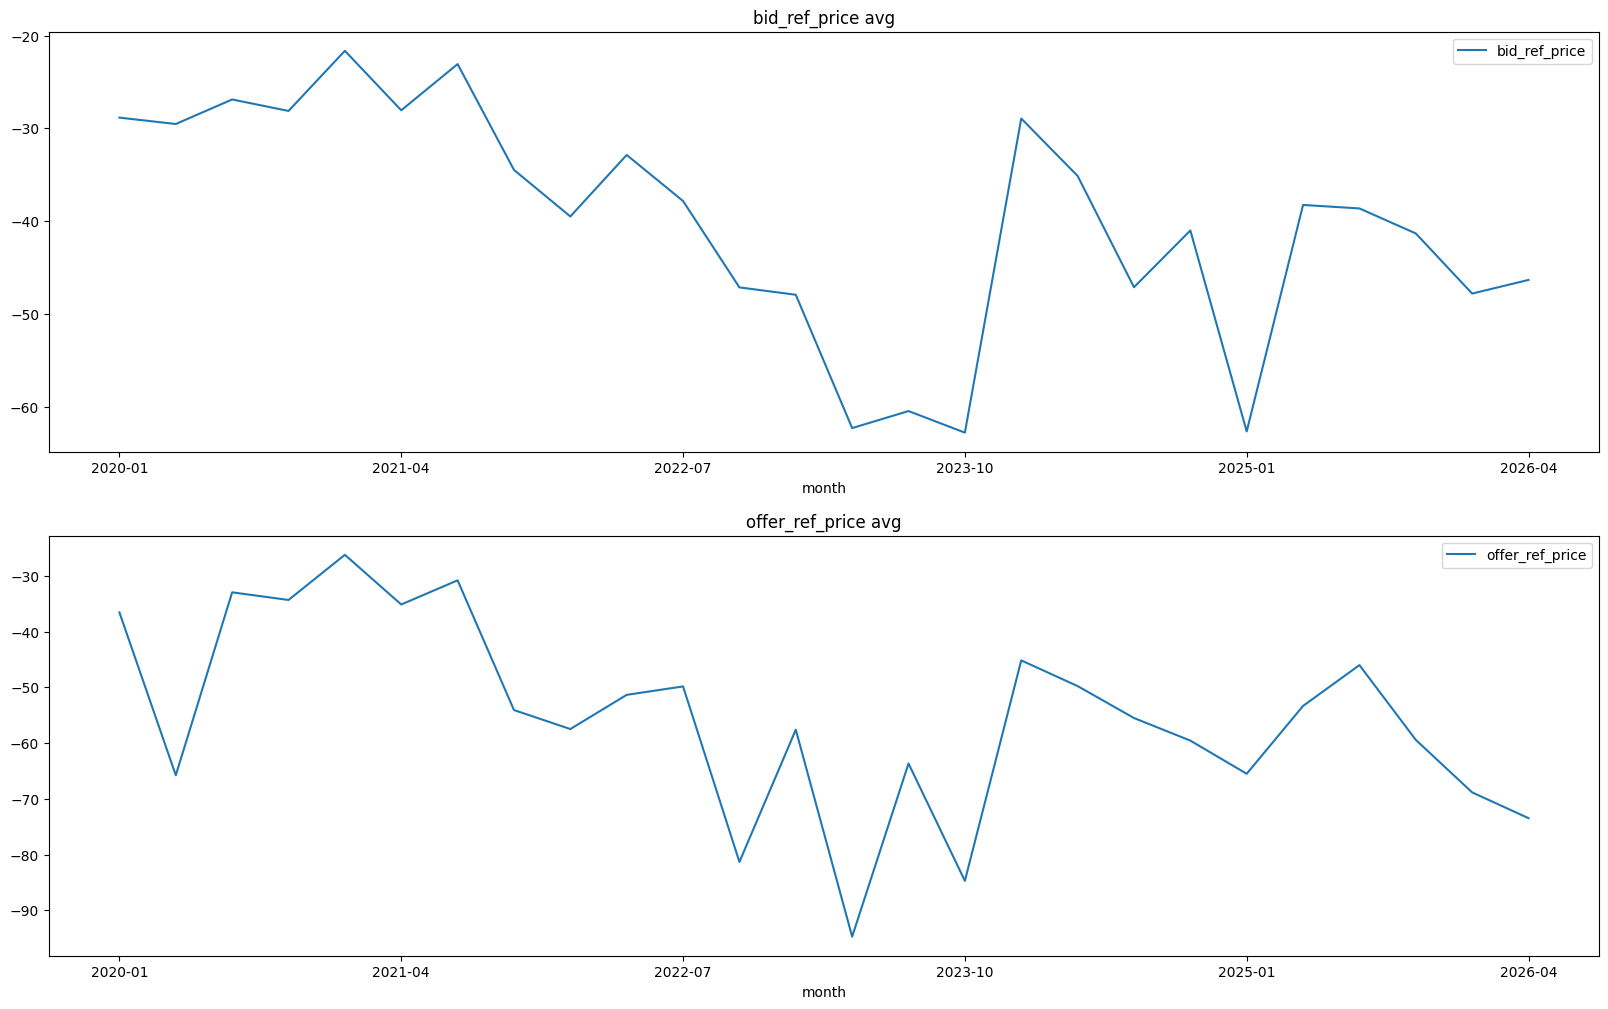

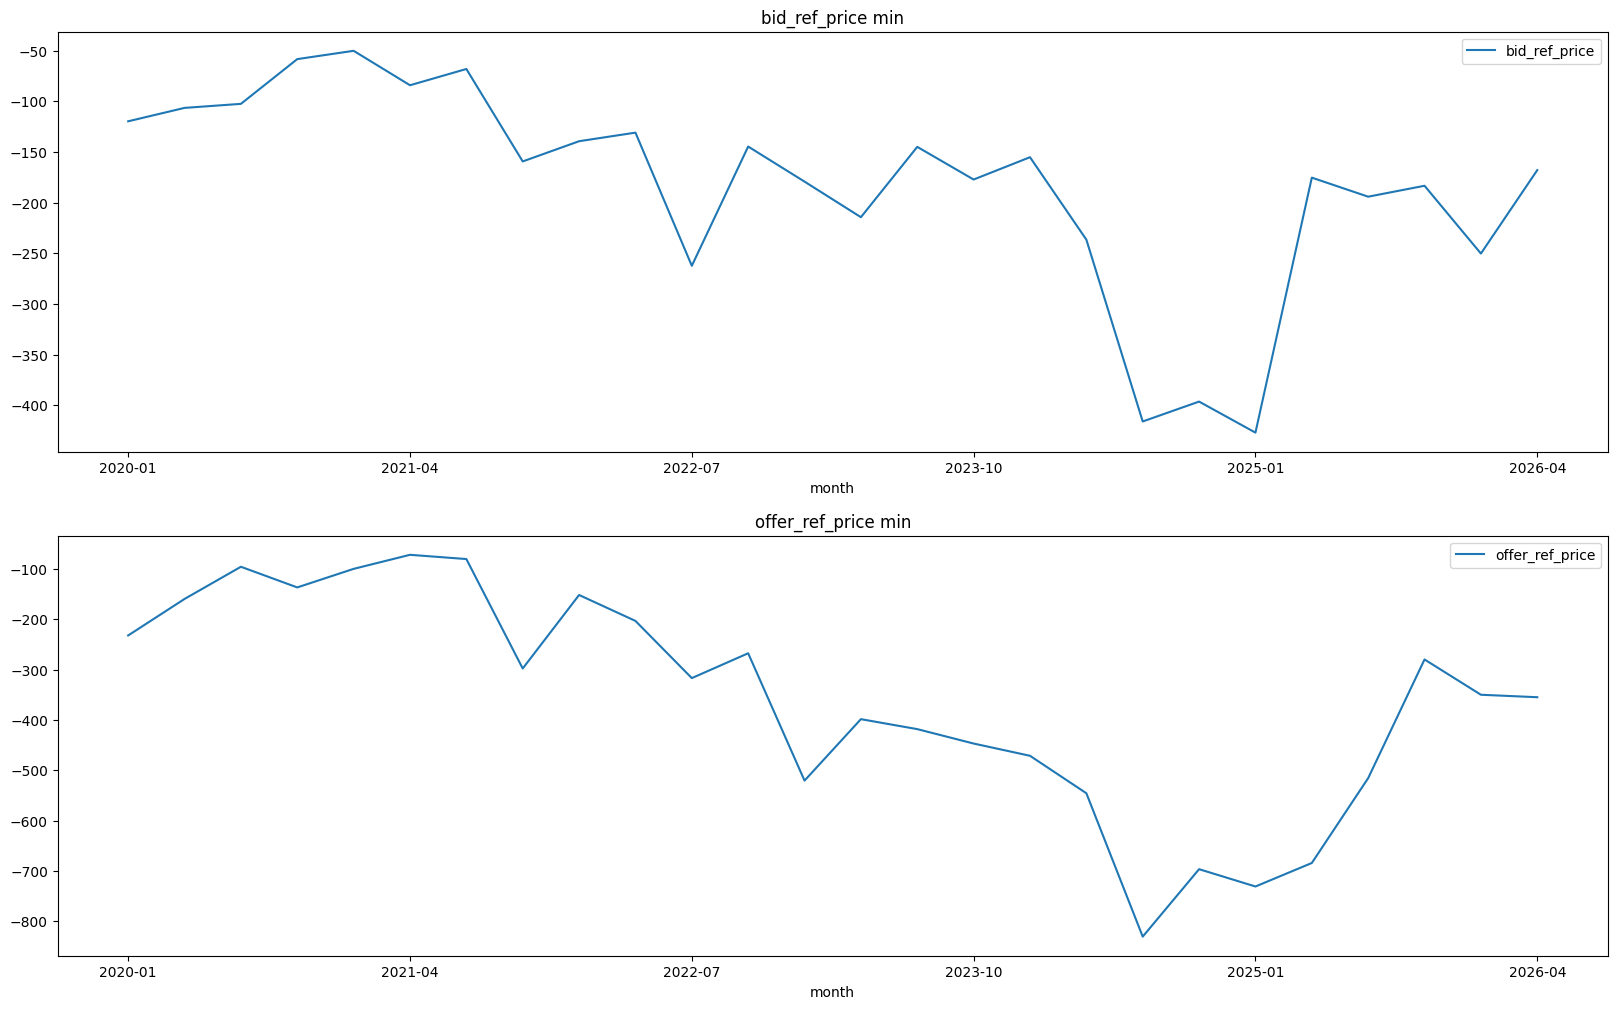

In [12]:
collateral_lst = ['bid_ref_price', 'offer_ref_price', ]

# avg
fig, ax = plt.subplots(len(collateral_lst), figsize=(20,12))
temp = ref_price_df.groupby(['month']).agg({'bid_ref_price': 'mean', 'offer_ref_price': 'mean'}).reset_index()
for col in collateral_lst:
    temp.plot('month', [col], ax=ax[collateral_lst.index(col)], title=col + ' avg')

# min
fig, ax = plt.subplots(len(collateral_lst), figsize=(20,12))
temp = ref_price_df.groupby(['month']).agg({'bid_ref_price': 'min', 'offer_ref_price': 'min'}).reset_index()
for col in collateral_lst:
    temp.plot('month', [col], ax=ax[collateral_lst.index(col)], title=col + ' min')


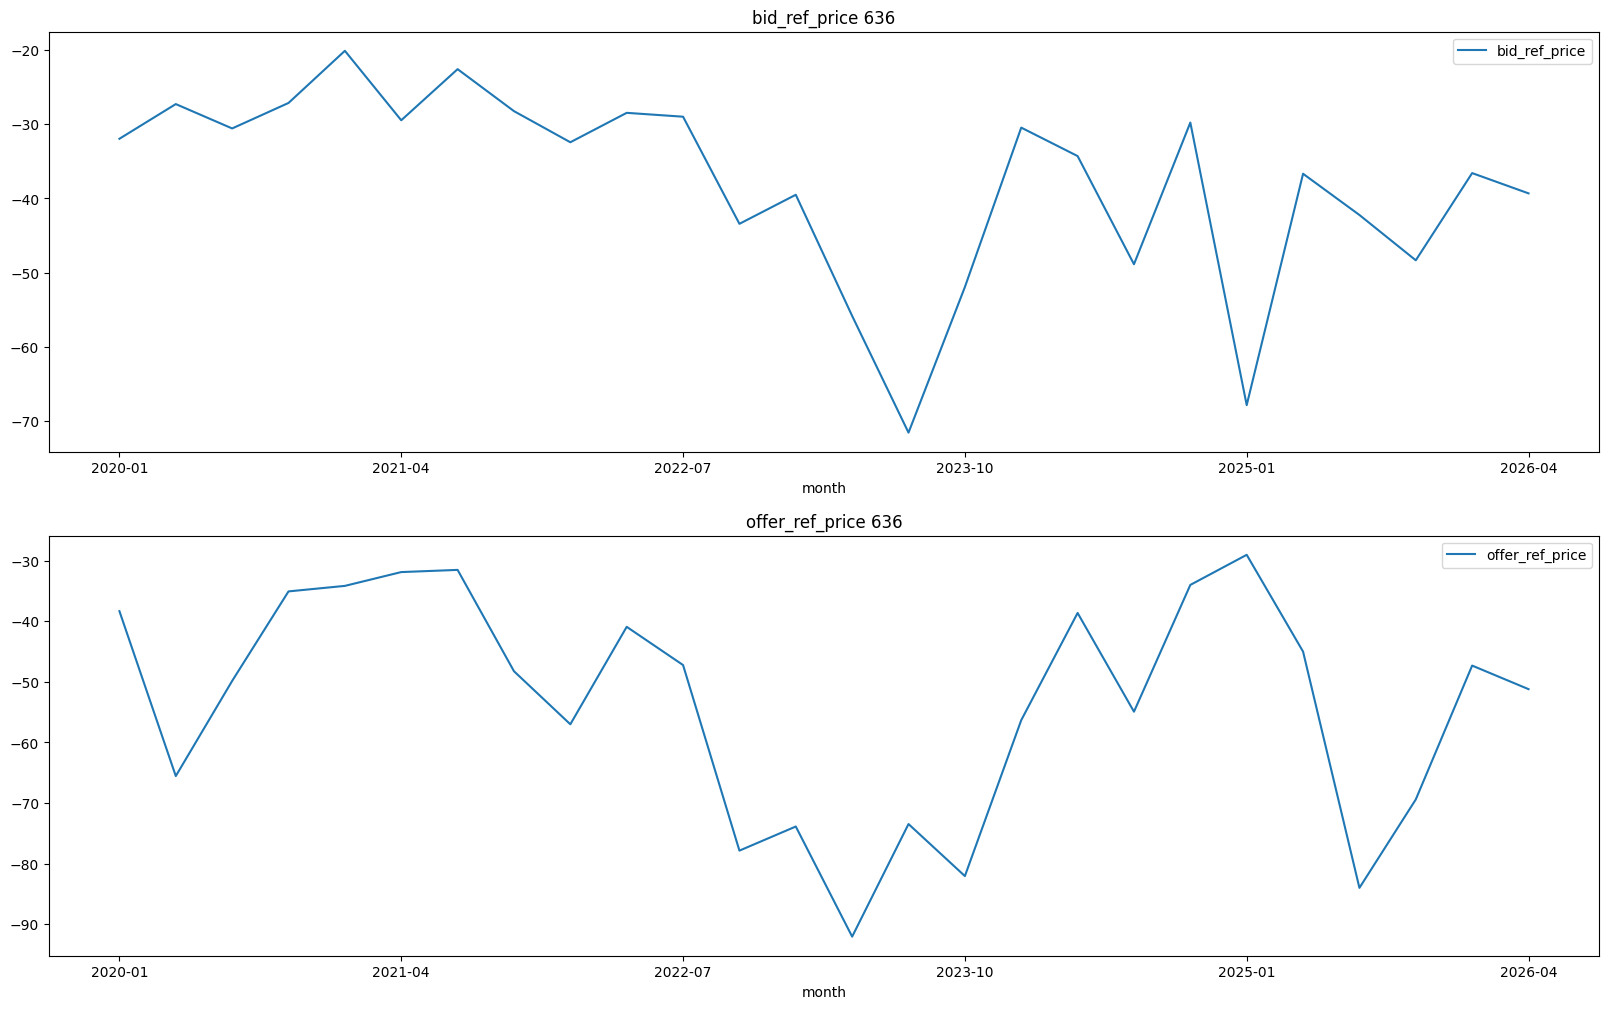

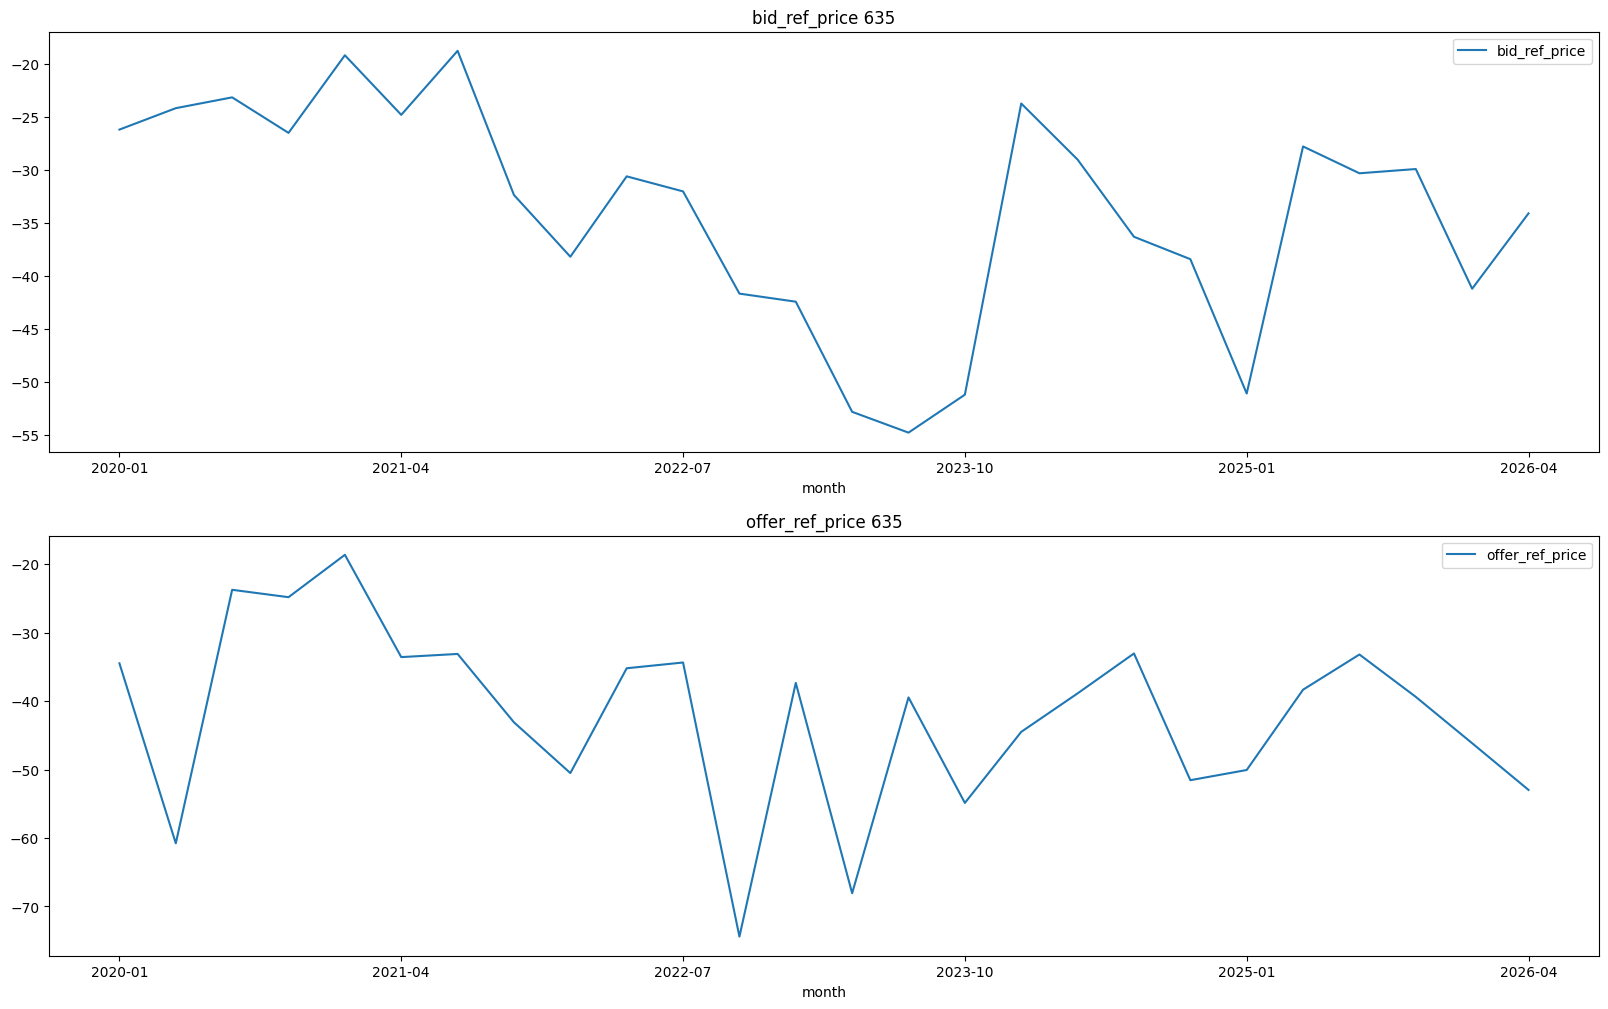

In [13]:
# 636
fig, ax = plt.subplots(len(collateral_lst), figsize=(20,12))
temp = ref_price_df[ref_price_df['node_num'] == 636].groupby(['month']).agg({'bid_ref_price': 'mean', 'offer_ref_price': 'mean'}).reset_index()
for col in collateral_lst:
    temp.plot('month', [col], ax=ax[collateral_lst.index(col)], title=col + ' 636')

# 635
fig, ax = plt.subplots(len(collateral_lst), figsize=(20,12))
temp = ref_price_df[ref_price_df['node_num'] == 635].groupby(['month']).agg({'bid_ref_price': 'mean', 'offer_ref_price': 'mean'}).reset_index()
for col in collateral_lst:
    temp.plot('month', [col], ax=ax[collateral_lst.index(col)], title=col + ' 635')


### portfolio collateral

In [ ]:
# estimate daily collateral
performance_cols = ['bid_mw', 'clear_mw', 'profit', 'profit_congestion', 'profit_neg', 'profit_pos', 'profit_slack']
collateral_df = portfolio_normal_df[['dt', 'bidCollateral', 'holdCollateral', ] + performance_cols].groupby('dt').sum().reset_index()
collateral_df['collateralClearRolling'] = collateral_df['holdCollateral'].rolling(9).sum()
collateral_df['collateralClearRolling'] = collateral_df['collateralClearRolling'] - collateral_df['holdCollateral']
collateral_df['collateral'] = collateral_df['collateralClearRolling'] + collateral_df['bidCollateral']


In [ ]:
# estimate collateral by dt, incdec
collateral_incdec_df = portfolio_normal_df[['dt', 'incdec', 'bidCollateral', 'holdCollateral', ] + performance_cols].groupby(['dt', 'incdec']).sum().reset_index()
collateral_incdec_df = collateral_incdec_df.pivot(index='dt', columns='incdec', values=['bidCollateral', 'holdCollateral'] + performance_cols).reset_index()
collateral_incdec_df.columns.name = None
collateral_incdec_df.columns = collateral_incdec_df.columns.map(lambda x: x[0] + '_' + x[1])
for col in ['Increment', 'Decrement']:
    collateral_incdec_df['collateralClearRolling_' + col] = collateral_incdec_df['holdCollateral_' + col].rolling(9).sum()
    collateral_incdec_df['collateralClearRolling_' + col] = collateral_incdec_df['collateralClearRolling_' + col] - collateral_incdec_df['holdCollateral_' + col]
    collateral_incdec_df['collateral_' + col] = collateral_incdec_df['collateralClearRolling_' + col] + collateral_incdec_df['bidCollateral_' + col]



In [16]:
# actual collateral

actual_collateral_df = sql_functions.download_df_from_sql_db(
    f"SELECT UpdateDateTime, Description, Value  FROM spp_virtual.credit_limit WHERE date(UpdateDateTime) >= '{start_dt}' AND Description in ('virtualMarketExposure', 'virtualAwardExposure', 'virtualEstimatedNotSettled')")
actual_collateral_df['UpdateDateTime'] = pd.to_datetime(actual_collateral_df['UpdateDateTime']).dt.tz_localize('UTC').dt.tz_convert('America/Chicago')
actual_collateral_df['dt'] = pd.to_datetime(actual_collateral_df['UpdateDateTime']).dt.strftime('%Y-%m-%d')
actual_collateral_df = actual_collateral_df.drop_duplicates(subset=['dt', 'Description'], keep='last')
actual_collateral_df['Value'] = -1*actual_collateral_df['Value']
collateral_detail_dict = {'virtualMarketExposure': 'bidCollateral',
                                  'virtualEstimatedNotSettled': 'collateral',
                                  'virtualAwardExposure': 'collateralClearRolling'}
actual_collateral_df['detail'] = actual_collateral_df['Description'].map(collateral_detail_dict)
actual_collateral_df = actual_collateral_df.pivot(index='dt', columns='detail', values='Value').reset_index()
actual_collateral_df.columns.name = None



In [17]:
collateral_df = collateral_df.merge(actual_collateral_df, on='dt', how='left', suffixes=('', '_actual'))

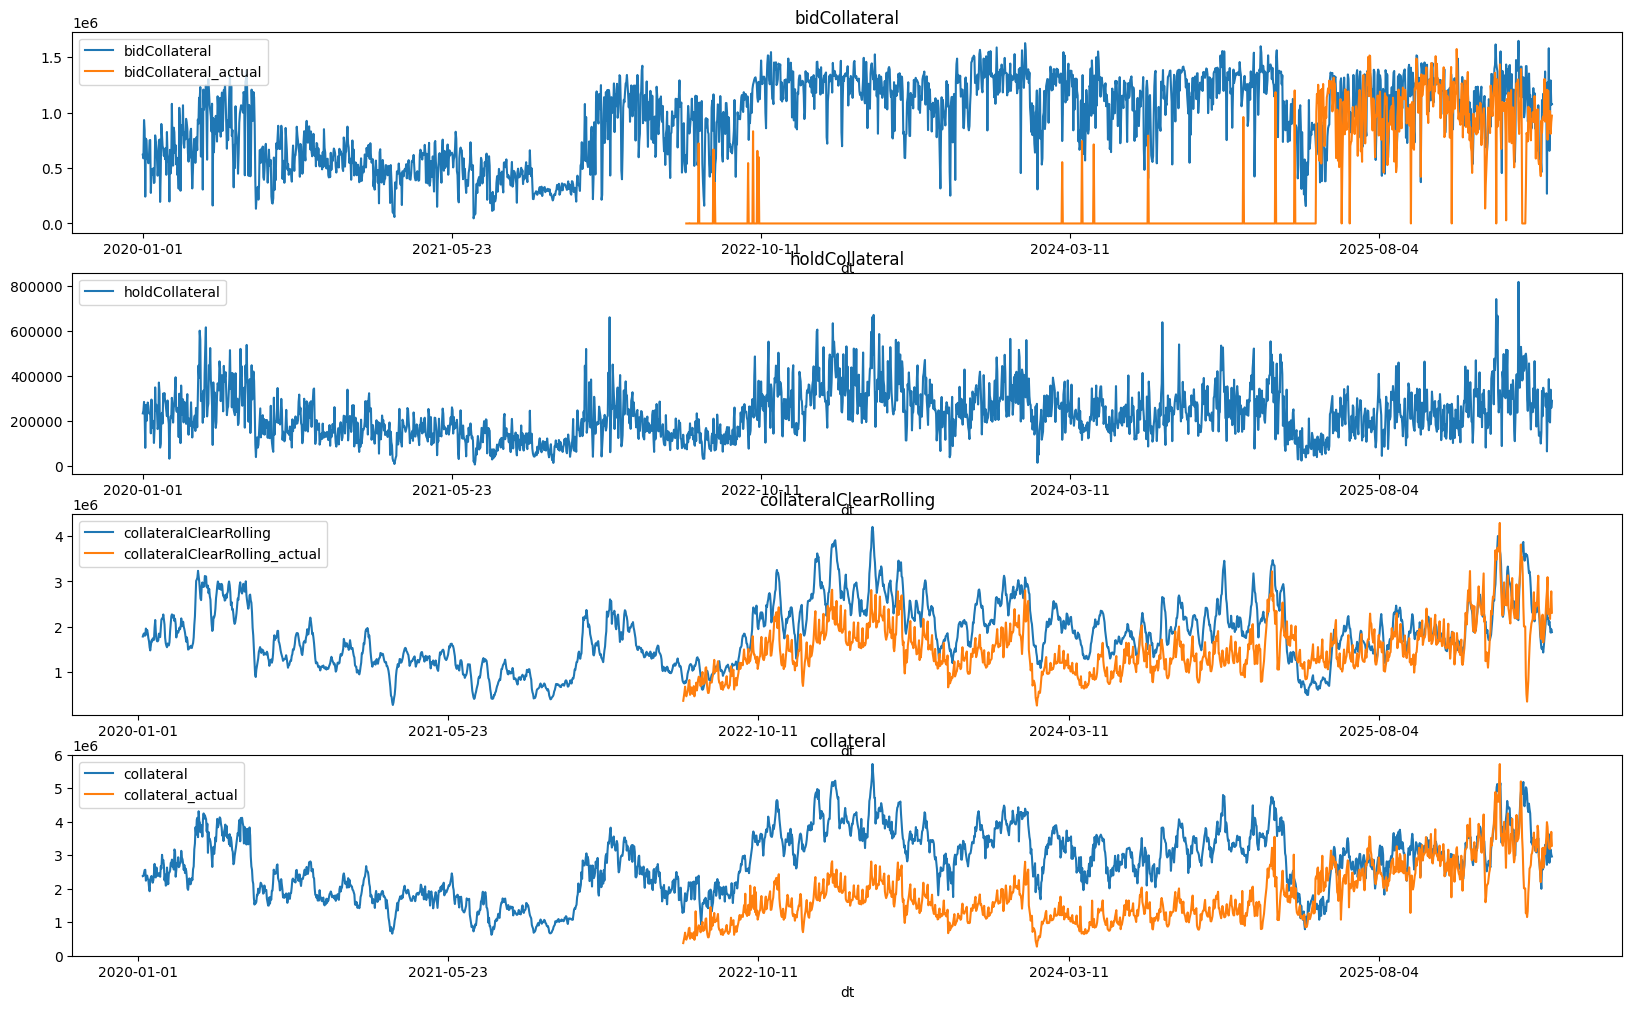

In [18]:
collateral_lst = ['bidCollateral', 'holdCollateral', 'collateralClearRolling', 'collateral']
fig, ax = plt.subplots(len(collateral_lst), figsize=(20,12))

for col in collateral_lst:
    col_lst = [col]
    if col + '_actual' in collateral_df.columns:
        col_lst.append(col + '_actual')
    collateral_df.plot('dt', col_lst, ax=ax[collateral_lst.index(col)], title=col)

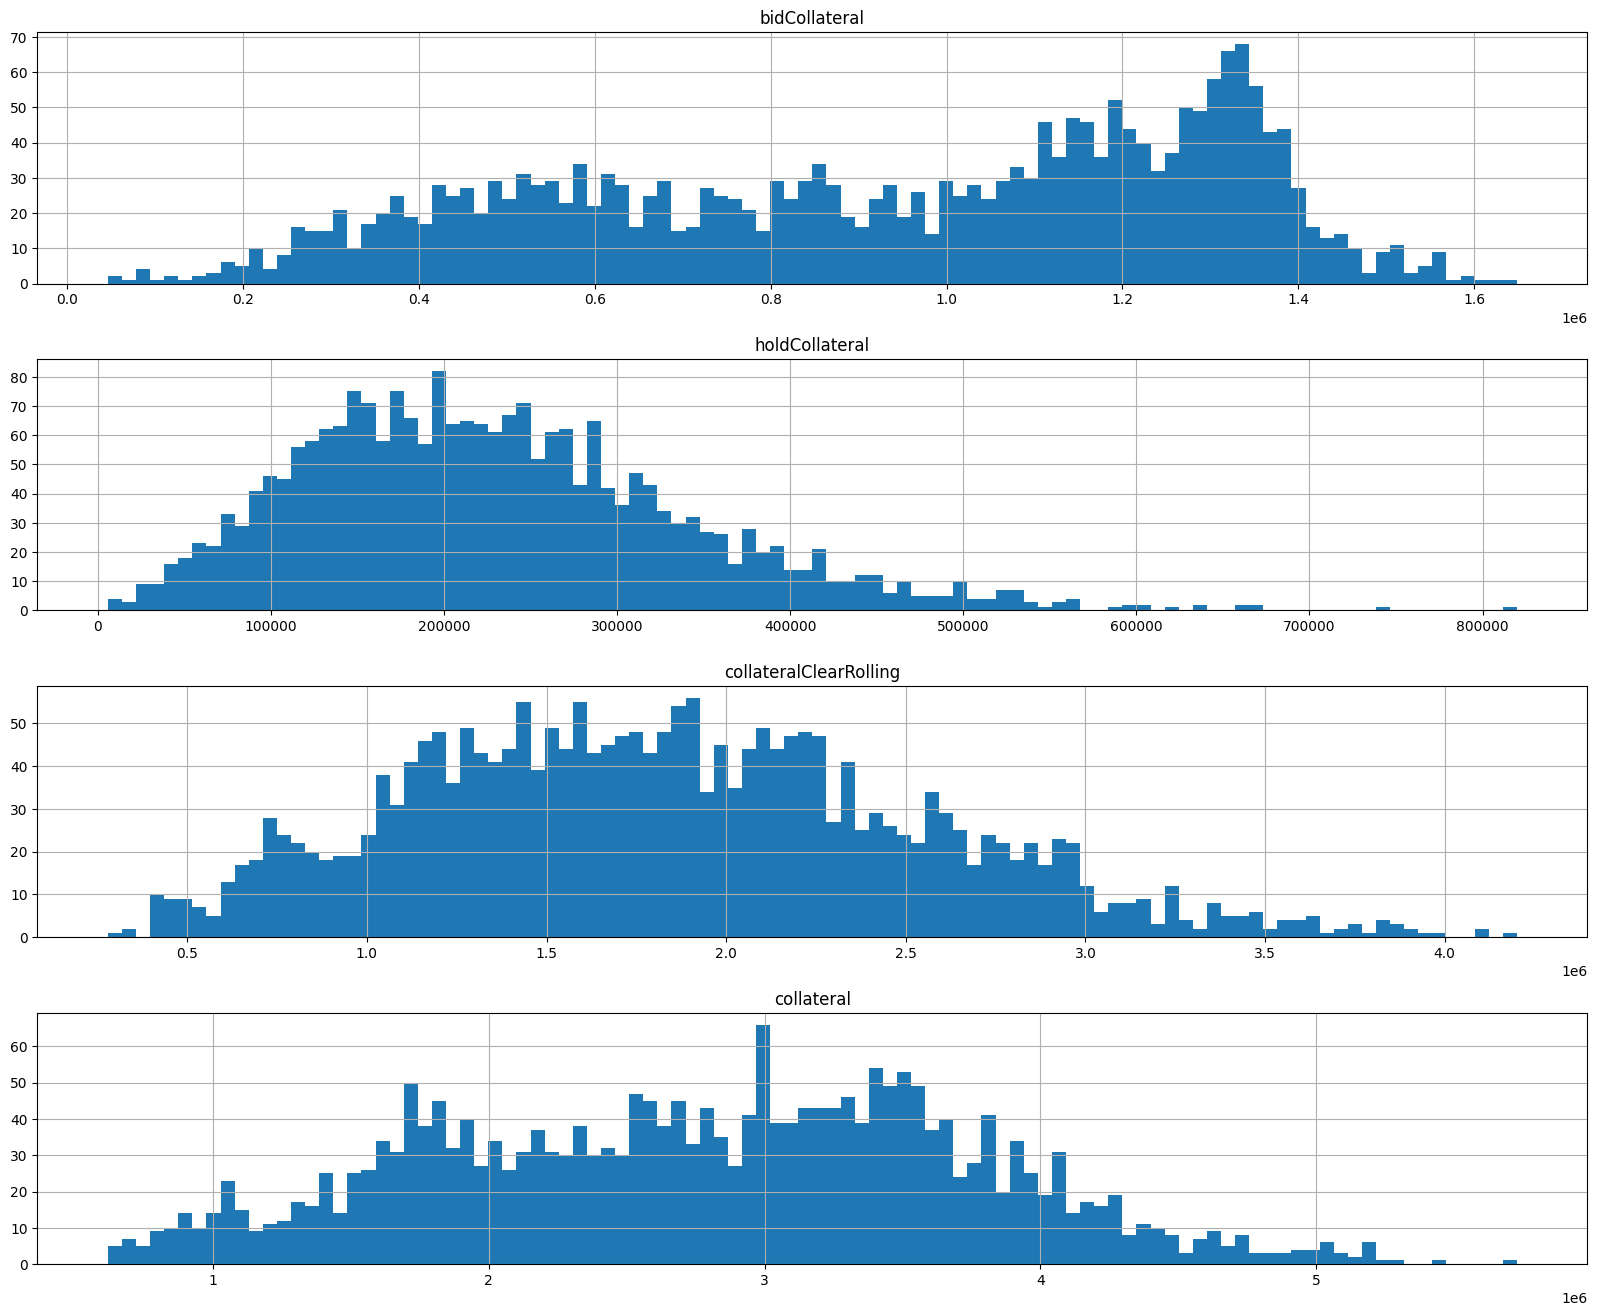

In [19]:
collateral_lst = ['bidCollateral', 'holdCollateral', 'collateralClearRolling', 'collateral']
fig, ax = plt.subplots(len(collateral_lst), figsize=(20,16))

for col in collateral_lst:
    collateral_df.hist(col, bins=100, ax=ax[collateral_lst.index(col)])

In [28]:
collateral_incdec_df.head()

,dt_,bidCollateral_Decrement,bidCollateral_Increment,holdCollateral_Decrement,holdCollateral_Increment,bid_mw_Decrement,bid_mw_Increment,clear_mw_Decrement,clear_mw_Increment,profit_Decrement,profit_Increment,profit_congestion_Decrement,profit_congestion_Increment,profit_neg_Decrement,profit_neg_Increment,profit_pos_Decrement,profit_pos_Increment,profit_slack_Decrement,profit_slack_Increment,collateralClearRolling_Increment,collateral_Increment,collateralClearRolling_Decrement,collateral_Decrement
0,2020-01-01,334902.362575,285612.535687,122889.886,110936.213,10332.196250,7621.782041,4086.8,2850.9,76859.61144,28629.38230,93313.67717,21789.89854,-8368.45477,-5663.25499,85228.06621,34292.63729,-11935.86846,10223.94009,NaN,NaN,NaN,NaN
1,2020-01-02,236451.986311,351475.598274,117958.443,128408.785,7334.733418,9134.098996,3777.9,3266.1,-1588.34461,7890.81061,-1984.01531,2220.16096,-7877.71193,-3792.32139,6289.36732,11683.13200,702.13489,9191.77712,NaN,NaN,NaN,NaN
2,2020-01-03,353166.235950,580534.270740,118962.555,165966.288,9560.492000,14072.734000,3364.4,4190.5,-3795.67900,24130.09196,6900.09730,5226.19907,-10537.97693,-5803.58706,6742.29793,29933.67902,-10204.32400,20113.78001,NaN,NaN,NaN,NaN
3,2020-01-04,234095.364301,605757.430890,41609.847,185394.829,6976.665011,14737.712653,1547.3,4936.9,-797.32692,50544.04375,8106.79546,14524.83553,-8698.98608,-3617.82367,7901.65916,54161.86742,-8044.11788,40168.13702,NaN,NaN,NaN,NaN
4,2020-01-05,66042.275000,176163.077350,32901.632,47171.515,1837.875000,4288.375000,856.0,1247.4,976.94112,18334.37493,7047.68208,10430.45417,-6389.04368,-617.86080,7365.98480,18952.23573,-5611.01904,9050.62950,NaN,NaN,NaN,NaN


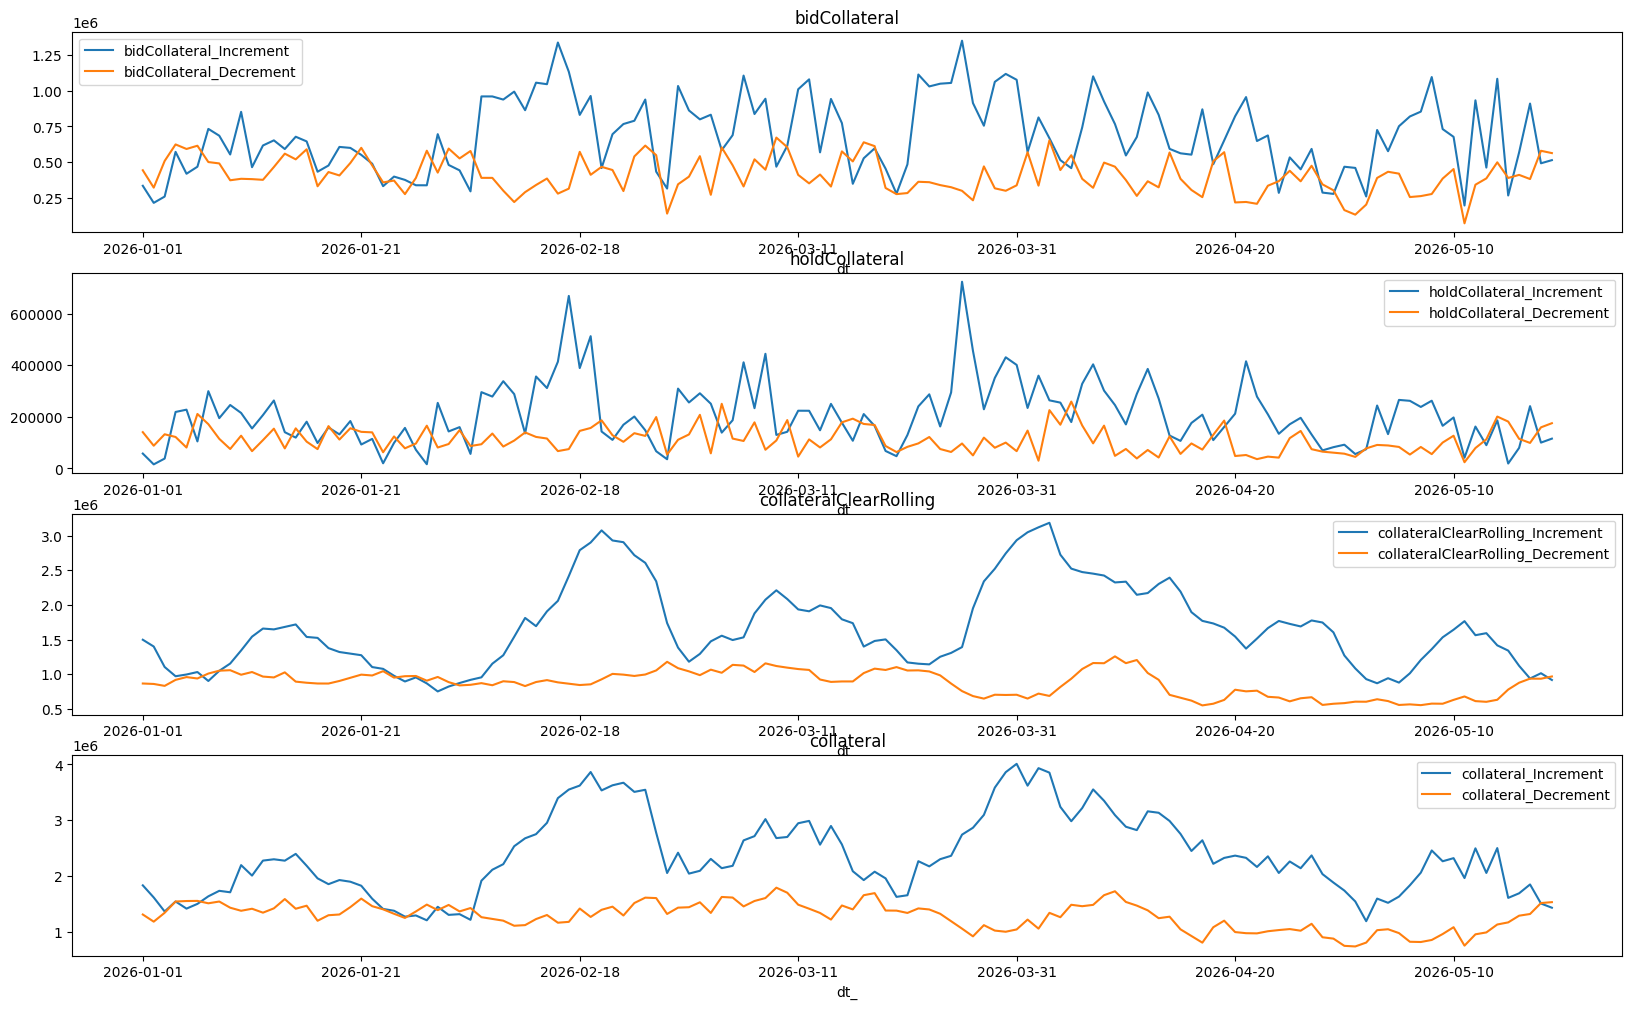

In [29]:
collateral_lst = ['bidCollateral', 'holdCollateral', 'collateralClearRolling', 'collateral']
fig, ax = plt.subplots(len(collateral_lst), figsize=(20,12))

for col in collateral_lst:
    col_lst = [col + '_Increment', col + '_Decrement']
    collateral_incdec_df[collateral_incdec_df['dt_'] >= '2026-01-01'].plot('dt_', col_lst, ax=ax[collateral_lst.index(col)], title=col)

In [ ]:
def sample_dt_performance(temp_dt, collateral_df, collateral_incdec_df):
    metric_cols = ['bidCollateral', 'holdCollateral', 'collateralClearRolling', 'collateral',] + performance_cols

    temp_df = collateral_df.loc[(collateral_df['dt'] >= (pd.to_datetime(temp_dt)-pd.Timedelta(days=30)).strftime('%Y-%m-%d'))&(collateral_df['dt'] <= (pd.to_datetime(temp_dt)+pd.Timedelta('30D')).strftime('%Y-%m-%d')), ['dt', ] + metric_cols].mean(numeric_only=True).to_frame().T
    temp_df['cr'] = temp_df['clear_mw'] / temp_df['bid_mw']
    temp_df['unit_bid'] = temp_df['bidCollateral'] / temp_df['bid_mw']
    temp_df['unit_hold'] = temp_df['holdCollateral'] / temp_df['clear_mw']
    display(temp_df.round(1))
    temp_df = collateral_df.loc[(collateral_df['dt'] >= (pd.to_datetime(temp_dt)-pd.Timedelta(days=9)).strftime('%Y-%m-%d'))&(collateral_df['dt'] <= pd.to_datetime(temp_dt).strftime('%Y-%m-%d')), ['dt', ] + metric_cols]
    temp_df['cr'] = temp_df['clear_mw'] / temp_df['bid_mw']
    temp_df['unit_bid'] = temp_df['bidCollateral'] / temp_df['bid_mw']
    temp_df['unit_hold'] = temp_df['holdCollateral'] / temp_df['clear_mw']
    display(temp_df.round(1))


    temp_df_1 =collateral_incdec_df.loc[(collateral_incdec_df['dt_'] >= (pd.to_datetime(temp_dt)-pd.Timedelta(days=30)).strftime('%Y-%m-%d'))&(collateral_incdec_df['dt_'] <= (pd.to_datetime(temp_dt)+pd.Timedelta('30D')).strftime('%Y-%m-%d')), ['dt_' ]+[col + '_Increment' for col in metric_cols]+[col + '_Decrement' for col in metric_cols]].mean(numeric_only=True).to_frame().T
    temp_df_1['cr_Increment'] = temp_df_1['clear_mw_Increment'] / temp_df_1['bid_mw_Increment']
    temp_df_1['cr_Decrement'] = temp_df_1['clear_mw_Decrement'] / temp_df_1['bid_mw_Decrement']
    temp_df_1['unit_bid_Increment'] = temp_df_1['bidCollateral_Increment'] / temp_df_1['bid_mw_Increment']
    temp_df_1['unit_bid_Decrement'] = temp_df_1['bidCollateral_Decrement'] / temp_df_1['bid_mw_Decrement']
    temp_df_1['unit_hold_Increment'] = temp_df_1['holdCollateral_Increment'] / temp_df_1['clear_mw_Increment']
    temp_df_1['unit_hold_Decrement'] = temp_df_1['holdCollateral_Decrement'] / temp_df_1['clear_mw_Decrement']


    temp_df_2 =collateral_incdec_df.loc[(collateral_incdec_df['dt_'] >= (pd.to_datetime(temp_dt)-pd.Timedelta(days=9)).strftime('%Y-%m-%d'))&(collateral_incdec_df['dt_'] <= pd.to_datetime(temp_dt).strftime('%Y-%m-%d')), ['dt_']+[col + '_Increment' for col in metric_cols]+[col + '_Decrement' for col in metric_cols]]
    temp_df_2['cr_Increment'] = temp_df_2['clear_mw_Increment'] / temp_df_2['bid_mw_Increment']
    temp_df_2['cr_Decrement'] = temp_df_2['clear_mw_Decrement'] / temp_df_2['bid_mw_Decrement']
    temp_df_2['unit_bid_Increment'] = temp_df_2['bidCollateral_Increment'] / temp_df_2['bid_mw_Increment']
    temp_df_2['unit_bid_Decrement'] = temp_df_2['bidCollateral_Decrement'] / temp_df_2['bid_mw_Decrement']
    temp_df_2['unit_hold_Increment'] = temp_df_2['holdCollateral_Increment'] / temp_df_2['clear_mw_Increment']
    temp_df_2['unit_hold_Decrement'] = temp_df_2['holdCollateral_Decrement'] / temp_df_2['clear_mw_Decrement']
    print('Increment')
    display(temp_df_1[[col for col in temp_df_1.columns if 'Increment' in col]].round(2))
    display(temp_df_2[[col for col in temp_df_2.columns if 'Increment' in col]].round(2))

    print('Decrement')
    display(temp_df_1[[col for col in temp_df_1.columns if 'Decrement' in col]].round(2))
    display(temp_df_2[[col for col in temp_df_2.columns if 'Decrement' in col]].round(2))

    return 

In [21]:
# top collateral days
display(collateral_df.round(1).sort_values('collateral', ascending=False).head(10))
display(collateral_df[collateral_df['dt'] >= '2026-01-01'].round(1).sort_values('collateral', ascending=False).head(10))

,dt,bidCollateral,holdCollateral,bid_mw,clear_mw,profit,profit_congestion,profit_neg,profit_pos,profit_slack,collateralClearRolling,collateral,bidCollateral_actual,collateral_actual,collateralClearRolling_actual
1184,2023-04-18,1526433.3,331669.4,18874.2,4355.3,24964.1,41721.6,-20320.6,45284.7,-5161.4,4201135.5,5727568.8,-0.0,2286550.0,2286550.0
1185,2023-04-19,1324674.4,173413.5,15274.8,2225.5,53255.3,51810.8,-20046.0,73301.4,4823.4,4100959.9,5425634.3,-0.0,2103420.0,2103420.0
1183,2023-04-17,1208137.3,466943.3,13285.6,5397.1,212969.5,230835.2,-27180.5,240149.9,-15209.7,4109895.9,5318033.2,-0.0,2391960.0,2391960.0
1124,2023-02-17,1320046.7,500107.4,22396.2,7743.3,7247.9,12122.5,-61403.8,68651.7,2481.9,3907805.6,5227852.3,-0.0,2046360.0,2046360.0
1123,2023-02-16,1316400.9,493682.7,19617.7,6051.6,54569.7,57536.8,-52820.2,107390.0,-4156.4,3884816.9,5201217.7,-0.0,2083130.0,2083130.0
2233,2026-04-03,1319598.8,489097.1,19613.3,6836.6,49544.0,63797.4,-81037.6,130581.6,-6420.6,3869966.7,5189565.5,-0.0,2449890.0,2449890.0
1119,2023-02-12,1377013.6,508630.6,19791.2,6719.8,90920.7,60132.6,-26780.3,117701.0,34013.7,3809373.8,5186387.4,-0.0,2816770.0,2816770.0
1122,2023-02-15,1335996.0,406551.7,21113.3,6068.5,50361.0,55158.6,-32624.0,82985.0,-4755.6,3848659.8,5184655.8,-0.0,2435960.0,2435960.0
1120,2023-02-13,1350762.3,428152.3,20177.6,6419.9,82660.4,45853.0,-25441.9,108102.3,39870.7,3821976.3,5172738.6,-0.0,2177570.0,2177570.0
1186,2023-04-20,1336204.0,326581.8,15622.2,3735.0,29549.9,48861.4,-41561.8,71111.7,-8684.8,3834654.4,5170858.3,-0.0,2118820.0,2118820.0


,dt,bidCollateral,holdCollateral,bid_mw,clear_mw,profit,profit_congestion,profit_neg,profit_pos,profit_slack,collateralClearRolling,collateral,bidCollateral_actual,collateral_actual,collateralClearRolling_actual
2233,2026-04-03,1319598.8,489097.1,19613.3,6836.6,49544.0,63797.4,-81037.6,130581.6,-6420.6,3869966.7,5189565.5,-0.0,2449890.0,2449890.0
2196,2026-02-24,1553453.7,273047.9,22880.5,4477.2,-76453.0,22245.1,-112775.5,36322.5,-94459.8,3601422.8,5154876.5,875037.0,4129320.0,3254280.0
2191,2026-02-19,1374168.8,668955.4,20678.9,9597.6,150418.7,140265.1,-33791.0,184209.6,29882.9,3753213.0,5127381.8,873302.0,4614230.0,3740930.0
2193,2026-02-21,1140098.8,238258.3,18995.1,4013.9,27596.6,19389.0,-34716.1,62312.6,10392.3,3933336.9,5073435.7,936645.0,4598420.0,3661770.0
2230,2026-03-31,1413747.1,467350.7,20362.6,6279.5,52154.5,46643.8,-27758.0,79912.5,18689.7,3636126.2,5049873.2,1063370.0,4466190.0,3402810.0
2190,2026-02-18,1402378.6,533832.6,19732.9,7065.2,92045.9,74762.6,-47543.9,139589.9,24198.0,3632383.3,5034761.9,1302790.0,4784240.0,3481450.0
2237,2026-04-07,1420413.6,499965.9,19903.6,6579.0,8068.2,8062.1,-66809.8,74878.0,10709.1,3611387.5,5031801.1,334475.0,1263250.0,928778.0
2195,2026-02-23,1329298.4,336961.0,19421.8,5154.6,33948.4,40667.6,-27326.6,61275.0,-1361.9,3691218.8,5020517.2,1436660.0,5725040.0,4288380.0
2238,2026-04-08,1420939.1,466768.7,23041.9,7149.0,-23958.0,968.3,-95460.2,71502.2,4533.2,3581150.5,5002089.6,815820.0,1335670.0,519853.0
2232,2026-04-02,1148192.2,388720.5,16863.5,5036.9,38627.5,31170.7,-35496.2,74123.8,17962.5,3838679.5,4986871.8,-0.0,3145280.0,3145280.0


In [25]:
temp_dt = '2023-04-18'
sample_dt_performance(temp_dt, collateral_df, collateral_incdec_df)

,bidCollateral,holdCollateral,collateralClearRolling,collateral,bid_mw,clear_mw,profit,profit_congestion,profit_neg,profit_pos,profit_slack,cr,unit_bid,unit_hold
0,1228056.3,359238.7,2904492.2,4132548.5,15684.4,4541.4,20021.6,27780.9,-39885.6,59907.2,-1455.9,0.3,78.3,79.1


,dt,bidCollateral,holdCollateral,collateralClearRolling,collateral,bid_mw,clear_mw,profit,profit_congestion,profit_neg,profit_pos,profit_slack,cr,unit_bid,unit_hold
1175,2023-04-09,1226803.2,375703.7,2334050.1,3560853.4,15743.2,5134.6,61658.3,67311.8,-25713.0,87371.3,5881.1,0.3,77.9,73.2
1176,2023-04-10,1035936.3,431845.1,2501020.0,3536956.3,12534.7,5015.9,12957.7,10771.3,-74817.2,87774.9,7577.5,0.4,82.6,86.1
1177,2023-04-11,1351299.1,439719.0,2659818.0,4011117.1,15487.5,5136.7,63349.2,124198.0,-27787.2,91136.4,-53070.7,0.3,87.3,85.6
1178,2023-04-12,1426383.4,597049.9,2774982.8,4201366.2,16155.4,6919.2,46892.6,70827.9,-49568.0,96460.6,-6748.6,0.4,88.3,86.3
1179,2023-04-13,1445559.1,434704.4,3177107.5,4622666.6,15604.5,4489.0,4961.3,4636.7,-57240.2,62201.5,13196.7,0.3,92.6,96.8
1180,2023-04-14,1381142.3,663387.7,3339451.9,4720594.2,15490.6,6974.6,-4381.7,-6094.5,-88520.7,84139.0,14043.0,0.5,89.2,95.1
1181,2023-04-15,1302099.7,494826.4,3627768.9,4929868.6,14938.3,5279.0,141179.6,158236.7,-28639.6,169819.2,-44.6,0.4,87.2,93.7
1182,2023-04-16,1334401.3,672659.9,3750169.9,5084571.2,14781.1,6774.6,21083.7,8946.0,-92051.4,113135.1,14604.5,0.5,90.3,99.3
1183,2023-04-17,1208137.3,466943.3,4109895.9,5318033.2,13285.6,5397.1,212969.5,230835.2,-27180.5,240149.9,-15209.7,0.4,90.9,86.5
1184,2023-04-18,1526433.3,331669.4,4201135.5,5727568.8,18874.2,4355.3,24964.1,41721.6,-20320.6,45284.7,-5161.4,0.2,80.9,76.2


,bidCollateral_Increment,holdCollateral_Increment,collateralClearRolling_Increment,collateral_Increment,bid_mw_Increment,clear_mw_Increment,profit_Increment,profit_congestion_Increment,profit_neg_Increment,profit_pos_Increment,profit_slack_Increment,cr_Increment,unit_bid_Increment,unit_hold_Increment
0,665062.88,178980.46,1489588.46,2154651.34,8162.18,2240.09,9943.68,14956.14,-16163.32,26107.0,-289.61,0.27,81.48,79.9


,bidCollateral_Increment,holdCollateral_Increment,collateralClearRolling_Increment,collateral_Increment,bid_mw_Increment,clear_mw_Increment,profit_Increment,profit_congestion_Increment,profit_neg_Increment,profit_pos_Increment,profit_slack_Increment,cr_Increment,unit_bid_Increment,unit_hold_Increment
1175,686610.63,168341.68,1397275.65,2083886.28,8735.04,2125.9,25806.17,10228.34,-6056.91,31863.07,22891.46,0.24,78.60,79.19
1176,490366.66,184695.76,1412514.06,1902880.72,5575.59,2254.2,-17354.88,-10641.36,-43471.85,26116.98,-3834.58,0.40,87.95,81.93
1177,981538.39,407353.15,1345553.47,2327091.86,11352.86,4600.1,34290.89,99888.37,-27135.52,61426.41,-58780.71,0.41,86.46,88.55
1178,1001431.16,536036.48,1520487.13,2521918.29,11202.17,6120.8,52404.39,77125.20,-38047.45,90451.84,-9104.17,0.55,89.40,87.58
1179,861022.09,276618.54,2007356.19,2868378.28,7999.19,2542.5,37690.06,24132.01,-15382.13,53072.19,22957.11,0.32,107.64,108.80
1180,847799.18,421244.78,2143739.73,2991538.91,8462.00,3616.7,7116.32,-10308.56,-23486.88,30603.21,26712.61,0.43,100.19,116.47
1181,684379.87,191427.70,2413880.32,3098260.19,6960.11,2185.5,441.73,17263.25,-11150.27,11592.00,-5371.66,0.31,98.33,87.59
1182,482261.63,171380.33,2394505.02,2876766.65,5942.24,2163.7,-46200.93,23318.63,-57338.84,11137.92,-67916.02,0.36,81.16,79.21
1183,477862.75,145965.14,2357098.43,2834961.18,5025.00,1762.6,35721.44,34704.92,-1124.82,36846.26,3296.14,0.35,95.10,82.81
1184,741343.67,203454.23,2334721.88,3076065.56,8482.41,2481.0,4228.27,18733.71,-7585.54,11813.80,-8060.26,0.29,87.40,82.00


,bidCollateral_Decrement,holdCollateral_Decrement,collateralClearRolling_Decrement,collateral_Decrement,bid_mw_Decrement,clear_mw_Decrement,profit_Decrement,profit_congestion_Decrement,profit_neg_Decrement,profit_pos_Decrement,profit_slack_Decrement,cr_Decrement,unit_bid_Decrement,unit_hold_Decrement
0,562993.43,180258.26,1414903.78,1977897.21,7522.17,2301.3,10077.91,12824.77,-23722.31,33800.22,-1166.26,0.31,74.84,78.33


,bidCollateral_Decrement,holdCollateral_Decrement,collateralClearRolling_Decrement,collateral_Decrement,bid_mw_Decrement,clear_mw_Decrement,profit_Decrement,profit_congestion_Decrement,profit_neg_Decrement,profit_pos_Decrement,profit_slack_Decrement,cr_Decrement,unit_bid_Decrement,unit_hold_Decrement
1175,540192.61,207362.01,936774.46,1476967.07,7008.20,3008.7,35852.13,57083.44,-19656.07,55508.20,-17010.32,0.43,77.08,68.92
1176,545569.66,247149.32,1088505.93,1634075.59,6959.16,2761.7,30312.56,21412.64,-31345.34,61657.90,11412.11,0.40,78.40,89.49
1177,369760.71,32365.84,1314264.49,1684025.20,4134.68,536.6,29058.31,24309.64,-651.66,29709.98,5709.97,0.13,89.43,60.32
1178,424952.23,61013.39,1254495.68,1679447.91,4953.23,798.4,-5511.82,-6297.29,-11520.55,6008.73,2355.58,0.16,85.79,76.42
1179,584536.99,158085.88,1169751.31,1754288.30,7605.26,1946.5,-32728.79,-19495.35,-41858.08,9129.30,-9760.40,0.26,76.86,81.22
1180,533343.10,242142.88,1195712.21,1729055.31,7028.63,3357.9,-11498.04,4214.03,-65033.83,53535.78,-12669.61,0.48,75.88,72.11
1181,617719.80,303398.68,1213888.62,1831608.42,7978.18,3093.5,140737.92,140973.50,-17489.32,158227.24,5327.10,0.39,77.43,98.08
1182,852139.63,501279.53,1355664.88,2207804.52,8838.89,4610.9,67284.64,-14372.62,-34712.57,101997.21,82520.49,0.52,96.41,108.72
1183,730274.51,320978.13,1752797.52,2483072.03,8260.65,3634.5,177248.04,196130.26,-26055.65,203303.69,-18505.86,0.44,88.40,88.31
1184,785089.61,128215.18,1866413.64,2651503.25,10391.83,1874.3,20735.85,22987.89,-12735.07,33470.92,2898.85,0.18,75.55,68.41


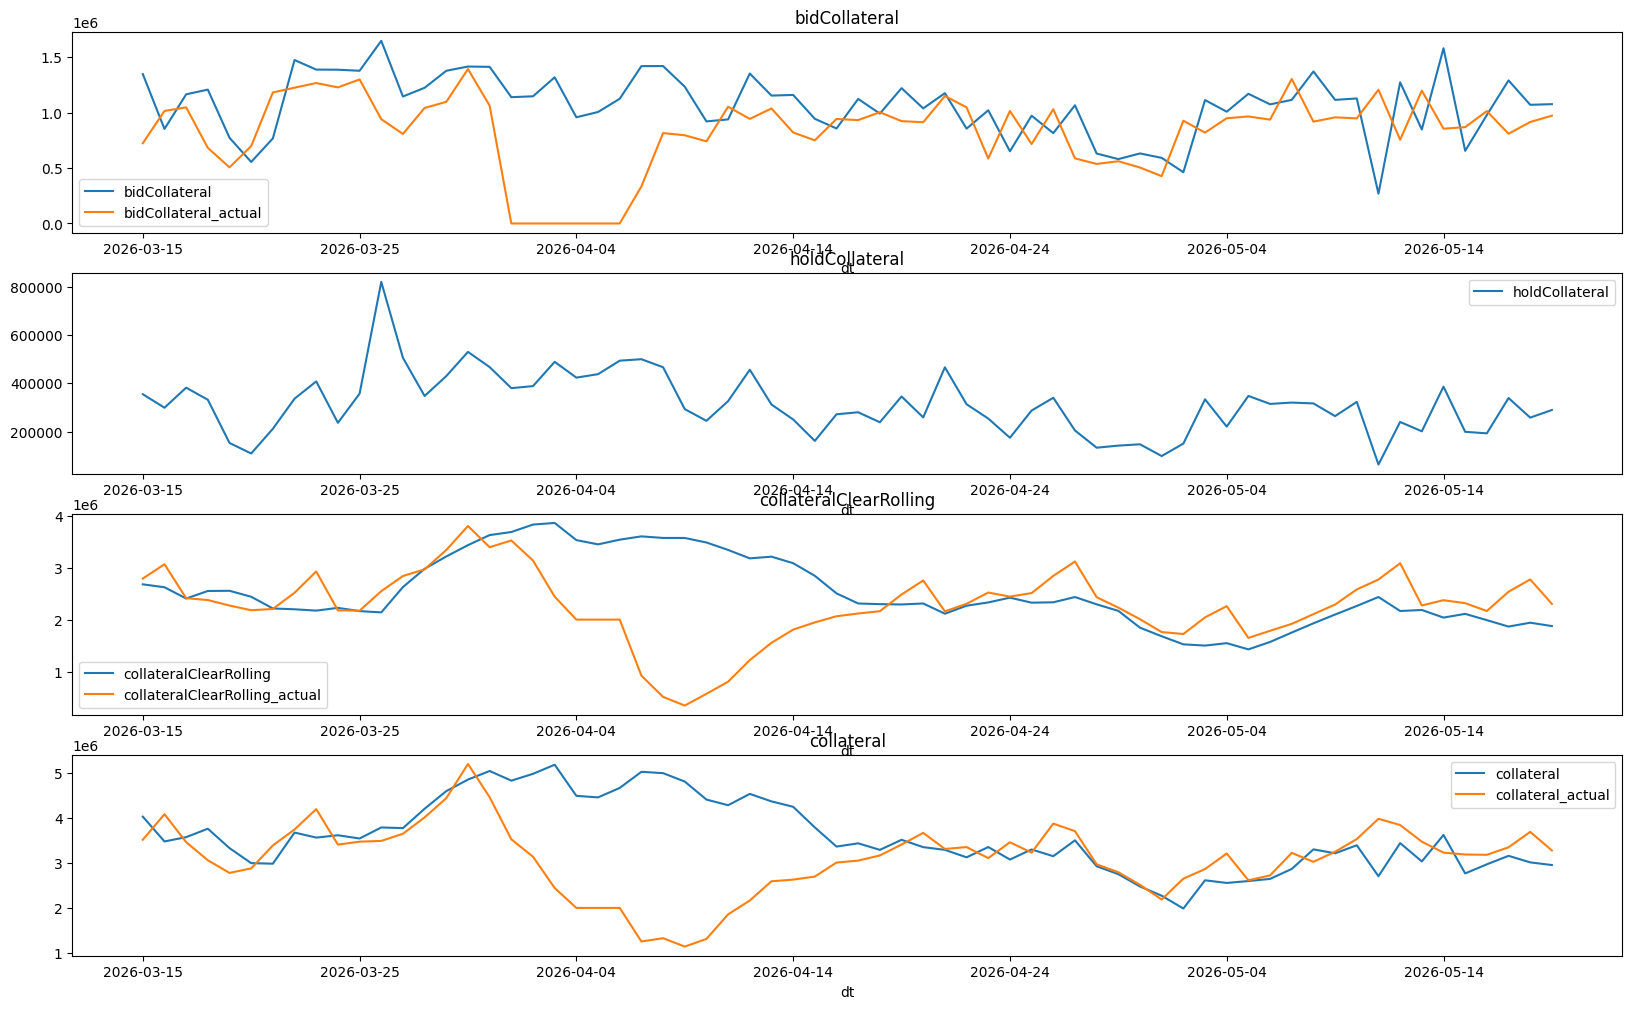

In [75]:
collateral_lst = ['bidCollateral', 'holdCollateral', 'collateralClearRolling', 'collateral']
fig, ax = plt.subplots(len(collateral_lst), figsize=(20,12))

for col in collateral_lst:
    col_lst = [col]
    if col + '_actual' in collateral_df.columns:
        col_lst.append(col + '_actual')
    collateral_df[collateral_df['dt'] >= '2026-03-15'].plot('dt', col_lst, ax=ax[collateral_lst.index(col)], title=col)

In [37]:
def display_cut_performance(temp, col):
    
    temp[col + '_bkt_label'] = pd.qcut(temp[col], q_lst)
    
    temp = temp.groupby([col + '_bkt_label']).agg({col: 'mean', 'dt': 'count', 'profit': 'sum', 'bid_mw': 'sum', 'clear_mw': 'sum', 'profit_congestion': 'sum',
    'profit_slack': 'sum', 'profit_pos': 'sum', 'profit_neg': 'sum'}).reset_index()
    temp['bid_mw_pct'] = temp['bid_mw'] / temp['bid_mw'].sum()
    temp['profit_pct'] = temp['profit'] / temp['profit'].sum()
    temp['profit_slack_pct'] = temp['profit_slack'] / temp['profit_slack'].sum()
    temp['tr'] = -temp['profit_pos'] / temp['profit_neg']
    temp['ppbw'] = temp['profit'] / temp['bid_mw']
    temp['ppcw'] = temp['profit'] / temp['clear_mw']
    display(temp.round(2))

In [38]:
q_lst = [0, 0.1, 0.5, 0.9, 0.95, 0.97, 0.985, 0.99, 0.995, 1]
display_cut_performance(collateral_df, 'collateral')
display_cut_performance(collateral_df[collateral_df['dt'] >= '2023-01-01'], 'collateral')

,collateral_bkt_label,collateral,dt,profit,bid_mw,clear_mw,profit_congestion,profit_slack,profit_pos,profit_neg,bid_mw_pct,profit_pct,profit_slack_pct,tr,ppbw,ppcw
0,"(619207.266, 1512106.509]",1146356.31,228,5687326.48,2360112.78,622817.6,5701001.77,1048168.74,10999977.20,-5312650.72,0.06,0.10,0.18,2.07,2.41,9.13
1,"(1512106.509, 2830259.102]",2184491.97,908,23205031.23,16009980.11,4077416.5,26169094.32,1614398.54,52788384.64,-29583353.41,0.40,0.39,0.28,1.78,1.45,5.69
2,"(2830259.102, 3980447.835]",3367917.77,908,24689402.58,17519802.12,4170958.3,27172258.68,2366523.64,63010319.19,-38320916.61,0.44,0.41,0.41,1.64,1.41,5.92
3,"(3980447.835, 4280804.36]",4119823.26,114,3585896.92,2184700.24,601392.9,3622623.37,397535.01,8040733.57,-4454836.65,0.05,0.06,0.07,1.80,1.64,5.96
4,"(4280804.36, 4534662.181]",4384125.25,45,844396.91,819540.18,229207.6,786258.51,365398.39,2940431.38,-2096034.47,0.02,0.01,0.06,1.40,1.03,3.68
5,"(4534662.181, 4814188.928]",4655947.08,34,1132008.05,646142.00,194122.4,1026408.23,341401.15,2554461.99,-1422453.94,0.02,0.02,0.06,1.80,1.75,5.83
6,"(4814188.928, 4980668.986]",4896478.04,12,-286729.19,218471.75,65002.7,130574.36,-344246.10,759424.24,-1046153.43,0.01,-0.00,-0.06,0.73,-1.31,-4.41
7,"(4980668.986, 5112184.013]",5038636.56,11,277874.22,213814.94,68765.4,315737.45,47821.52,870196.42,-592322.20,0.01,0.00,0.01,1.47,1.30,4.04
8,"(5112184.013, 5727568.809]",5257230.85,12,730008.46,229325.56,69627.4,830340.14,-27775.85,1265791.58,-535783.12,0.01,0.01,-0.00,2.36,3.18,10.48


,collateral_bkt_label,collateral,dt,profit,bid_mw,clear_mw,profit_congestion,profit_slack,profit_pos,profit_neg,bid_mw_pct,profit_pct,profit_slack_pct,tr,ppbw,ppcw
0,"(785035.722, 2365873.652]",1852550.08,121,1542896.64,1573169.86,282156.5,1835874.28,100978.46,4654444.39,-3111547.75,0.07,0.06,0.04,1.50,0.98,5.47
1,"(2365873.652, 3274058.94]",2886745.60,481,10231231.04,9117721.73,1933389.6,11448532.59,751182.67,29466677.32,-19235446.27,0.41,0.40,0.31,1.53,1.12,5.29
2,"(3274058.94, 4235151.092]",3674791.15,480,11274607.92,9095378.03,2189657.9,12521037.01,1075235.36,32722062.82,-21447454.90,0.41,0.44,0.45,1.53,1.24,5.15
3,"(4235151.092, 4568577.79]",4372806.46,60,1216186.77,1096062.19,305195.6,1138380.24,447152.51,3951472.87,-2735286.10,0.05,0.05,0.19,1.44,1.11,3.98
4,"(4568577.79, 4787619.141]",4670657.54,24,751490.84,449190.09,137726.4,629968.42,307079.75,1768121.17,-1016630.34,0.02,0.03,0.13,1.74,1.67,5.46
5,"(4787619.141, 5031462.592]",4909651.67,18,-124909.71,341743.15,98912.3,290486.21,-287213.93,1214223.86,-1339133.57,0.02,-0.00,-0.12,0.91,-0.37,-1.26
6,"(5031462.592, 5084348.455]",5052451.10,6,208729.47,119904.70,38839.0,211494.10,31520.11,485246.06,-276516.59,0.01,0.01,0.01,1.75,1.74,5.37
7,"(5084348.455, 5186370.114]",5149180.36,6,257620.80,115253.58,37072.8,321329.30,-23542.27,595866.34,-338245.54,0.01,0.01,-0.01,1.76,2.24,6.95
8,"(5186370.114, 5727568.809]",5325179.89,7,493471.37,128853.10,39329.2,517956.84,10370.88,783060.37,-289589.00,0.01,0.02,0.00,2.70,3.83,12.55


In [ ]:
cutoff = 5000000
collateral_df['collateral_cutoff'] = np.where(collateral_df['collateral'] > cutoff, cutoff, collateral_df['collateral'])
display_cut_performance(collateral_df, 'collateral_cutoff')
display_cut_performance(collateral_df[collateral_df['dt'] >= '2023-01-01'], 'collateral_cutoff')


,dt,bidCollateral,holdCollateral,bid_mw,clear_mw,profit,profit_congestion,profit_neg,profit_pos,profit_slack,collateralClearRolling,collateral,collateral_bkt_label
0,2020-01-01,6.205149e+05,233826.099,17953.978291,6937.7,105488.99374,115103.57571,-14031.70976,119520.70350,-1711.92837,NaN,NaN,NaN
1,2020-01-02,5.879276e+05,246367.228,16468.832413,7044.0,6302.46600,236.14565,-11670.03332,17972.49932,9893.91201,NaN,NaN,NaN
2,2020-01-03,9.337005e+05,284928.843,23633.226000,7554.9,20334.41296,12126.29637,-16341.56399,36675.97695,9909.45601,NaN,NaN,NaN
3,2020-01-04,8.398528e+05,227004.676,21714.377663,6484.2,49746.71683,22631.63099,-12316.80975,62063.52658,32124.01914,NaN,NaN,NaN
4,2020-01-05,2.422054e+05,80073.147,6126.250000,2103.4,19311.31605,17478.13625,-7006.90448,26318.22053,3439.61046,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2275,2026-05-15,6.556580e+05,199598.783,9406.223000,2977.6,1749.37821,37871.19198,-46818.03772,48567.41593,-32675.78015,2318187.288,2.774246e+06,"(1512106.509, 2830259.102]"
2276,2026-05-16,9.791542e+05,193296.950,15278.774000,2839.2,-15825.71114,-6974.84995,-28547.16682,12721.45568,-5452.06140,2190907.950,2.976765e+06,"(2830259.102, 3980447.835]"
2277,2026-05-17,1.291422e+06,339405.625,18645.241192,5302.2,12651.18818,24388.92733,-67299.68080,79950.86898,1.05868,2213276.903,3.165293e+06,"(2830259.102, 3980447.835]"
2278,2026-05-18,1.071205e+06,258345.651,17021.384452,4150.0,71212.43040,64334.21416,-41235.27797,112447.70837,15281.20987,2207028.645,3.019888e+06,"(2830259.102, 3980447.835]"
